<a href="https://colab.research.google.com/github/LUCASEPITACIO12/LUCASEPITACIO12/blob/main/Relat%C3%B3rio_Integrado_de_Abastecimento_de_Agua_Alagoas_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Relatorio Integrado de Abastecimento de Agua - Alagoas 2026
### SISAGUA x Censo IBGE 2022 | Cobertura - Qualidade - Auditoria Cadastral

| | |
|---|---|
| **Fonte principal** | SISAGUA - Cadastro de Solucoes de Abastecimento de Agua (ref. 2026) |
| **Fonte demografica** | IBGE - Previa do Censo Demografico 2022 |
| **Base normativa** | Portaria GM/MS n. 888, de 4 de maio de 2021 |
| **Elaborado por** | SEVISA / SESAU-AL - Vigilancia da Qualidade da Agua para Consumo Humano |

---

## Estrutura
1. Configuracao e importacao dos dados
2. Panorama estadual - SAA, SAC e SAI
3. Cobertura real - SISAGUA x IBGE 2022
4. Qualidade da infraestrutura - desinfeccao e filtracao
5. Auditoria cadastral - anomalias identificadas
6. Sintese executiva e recomendacoes

---

> **Nota metodologica - filtracao:** Considera apenas sistemas com captacao superficial (SAA e SAC).
> Sistemas com captacao subterranea serao incluidos somente apos cruzamento com resultados
> laboratoriais do SISAGUA (analise complementar prevista).

## 1. Configuracao e Importacao dos Dados

In [1]:
# @title Configuracao do ambiente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import unicodedata, warnings
warnings.filterwarnings('ignore')

CORES_TIPO = {'SAA':'#1a6b9b', 'SAC':'#2ca25f', 'SAI':'#e07b39'}
CORES_COB  = {
    'Adequada (>=80%)':'#2ca25f', 'Parcial (50-79%)':'#f0a500',
    'Insuficiente (20-49%)':'#e07b39', 'Critica (<20%)':'#c0392b',
    'Sem registro':'#aaaaaa',
}
CORES_ERR = {
    'SAC/SAI superestimado':'#e07b39',
    'SAI classificado incorretamente':'#9b59b6',
    'Duplicidade de populacao':'#e74c3c',
    'Ausencia de SAA':'#7f8c8d',
}
BG = '#f8f9fa'
plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':BG,
    'axes.grid':True,'grid.color':'#dee2e6','grid.linewidth':0.7,
    'axes.spines.top':False,'axes.spines.right':False,
    'font.family':'DejaVu Sans','axes.titlesize':13,'axes.labelsize':11,
    'xtick.labelsize':9.5,'ytick.labelsize':9.5,
})

def normalizar(s):
    s = s.upper().strip()
    s = unicodedata.normalize('NFD', s)
    return ''.join(c for c in s if unicodedata.category(c) != 'Mn')

def cor_cob(v):
    if v>=80: return '#2ca25f'
    if v>=50: return '#f0a500'
    if v>=20: return '#e07b39'
    return '#c0392b'

print('Ambiente configurado.')

Ambiente configurado.


In [2]:
# @title Importacao dos dados SISAGUA
# SISAGUA
df = pd.read_csv('/content/cadastro_populacao_abastecida_AL.csv',
                 encoding='latin-1', sep=None, engine='python')
df['POP']       = df['NU_VALOR_POPULACAO_ESTIMADA'].fillna(0)
df['POP_RURAL'] = df['NU_VALOR_RURAL'].fillna(0)
df['POP_URBAN'] = df['NU_VALOR_URBANA'].fillna(0)
df['ECON_PERM'] = df['NU_ECONOMIA_DOMICILIO_PERMAN'].fillna(0)
df['DESINF']    = (df['DESINFECCAO'] == 'Sim').astype(int)
df['FILTR']     = (df['FILTRACAO']   == 'Sim').astype(int)
df['SUP']       = (df['CAPTACAO_SUPERFICIAL']  == 'Sim').astype(int)
df['SUB']       = (df['CAPTACAO_SUBTERRANEA']  == 'Sim').astype(int)
df['KEY']       = df['NO_MUNICIPIO'].apply(normalizar)
LABEL_MAP = {
    '01 REGIAO MCZ AL':'MCZ (01)','02 REGIAO MRG AL':'MRG (02)',
    '03 REGIAO UDP AL':'UDP (03)','04 REGIAO ATL AL':'ATL (04)',
    '05 REGIAO SMC AL':'SMC (05)','06 REGIAO COR AL':'COR (06)',
    '07 REGIAO ARP AL':'ARP (07)','08 REGIAO PLM AL':'PLM (08)',
    '09 REGIAO STI AL':'STI (09)','10 REGIAO DEG AL':'DEG (10)',
}
df['REGIONAL'] = df['NO_REGIONAL'].map(LABEL_MAP)
# fallback para regional nao mapeada
df['REGIONAL'] = df['REGIONAL'].fillna(df['NO_REGIONAL'])

print(f'Registros SISAGUA  : {len(df):,}')
print(f'Municipios         : {df["NO_MUNICIPIO"].nunique()}')
print(f'Tipos              : {sorted(df["TP_ABASTECIMENTO"].unique())}')

Registros SISAGUA  : 1,970
Municipios         : 101
Tipos              : ['SAA', 'SAC', 'SAI']


In [3]:
# @title Importacao dos dados IBGE 2022
# IBGE Censo 2022 - fonte: FTP IBGE AL_POP2022.pdf
ibge_dados = [
    ('Agua Branca',19011),('Anadia',13960),('Arapiraca',235085),('Atalaia',37356),
    ('Barra de Santo Antonio',16405),('Barra de Sao Miguel',7952),('Batalha',16016),
    ('Belem',4589),('Belo Monte',5935),('Boca da Mata',21175),('Branquinha',9474),
    ('Cacimbinhas',10387),('Cajueiro',16035),('Campestre',6656),('Campo Alegre',32020),
    ('Campo Grande',8138),('Canapi',15434),('Capela',15023),('Carneiros',8992),
    ('Cha Preta',5908),('Coite do Noia',10791),('Colonia Leopoldina',15673),
    ('Coqueiro Seco',5579),('Coruripe',49951),('Craibas',25330),
    ('Delmiro Gouveia',51215),('Dois Riachos',9754),('Estrela de Alagoas',15322),
    ('Feira Grande',22701),('Feliz Deserto',3947),('Flexeiras',9520),
    ('Girau do Ponciano',35899),('Ibateguara',13699),('Igaci',23996),
    ('Igreja Nova',21227),('Inhapi',15158),('Jacare dos Homens',5071),
    ('Jacuipe',5340),('Japaratinga',9307),('Jaramataia',4992),
    ('Jequia da Praia',9480),('Joaquim Gomes',17080),('Jundia',4088),
    ('Junqueiro',23902),('Lagoa da Canoa',18480),('Limoeiro de Anadia',24698),
    ('Maceio',960667),('Major Isidoro',18081),('Maragogi',32540),('Maravilha',9515),
    ('Marechal Deodoro',61177),('Maribondo',13677),('Mar Vermelho',3155),
    ('Mata Grande',21627),('Matriz de Camaragibe',23871),('Messias',15418),
    ('Minador do Negrao',4838),('Monteiropolis',7201),('Murici',25221),
    ('Novo Lino',10011),('Olho dAgua das Flores',20702),('Olho dAgua do Casado',8345),
    ('Olho dAgua Grande',4333),('Olivenca',10744),('Ouro Branco',11382),
    ('Palestina',4328),('Palmeira dos Indios',68534),('Pao de Acucar',23721),
    ('Pariconha',10573),('Paripueira',13991),('Passo de Camaragibe',13870),
    ('Paulo Jacinto',6570),('Penedo',58654),('Piacabucu',15834),('Pilar',35433),
    ('Pindoba',2734),('Piranhas',22589),('Poco das Trincheiras',12480),
    ('Porto Calvo',23708),('Porto de Pedras',9373),('Porto Real do Colegio',20048),
    ('Quebrangulo',11069),('Rio Largo',93729),('Roteiro',6482),
    ('Santa Luzia do Norte',6946),('Santana do Ipanema',46258),
    ('Santana do Mundau',11307),('Sao Bras',6463),('Sao Jose da Laje',20742),
    ('Sao Jose da Tapera',30359),('Sao Luis do Quitunde',30922),
    ('Sao Miguel dos Campos',51978),('Sao Miguel dos Milagres',8711),
    ('Sao Sebastiao',31788),('Satuba',24087),('Senador Rui Palmeira',12300),
    ('Tanque dArca',5746),('Taquarana',19004),('Teotonio Vilela',37999),
    ('Traipu',23486),('Uniao dos Palmares',59093),('Vicosa',24089),
]
df_ibge = pd.DataFrame(ibge_dados, columns=['MUNICIPIO_IBGE','POP_IBGE'])
df_ibge['KEY'] = df_ibge['MUNICIPIO_IBGE'].apply(normalizar)
print(f'Municipios IBGE: {len(df_ibge)}')
print(f'Pop. total AL (Censo 2022): {df_ibge["POP_IBGE"].sum():,} hab.')

Municipios IBGE: 102
Pop. total AL (Censo 2022): 3,125,254 hab.


## 2. Panorama Estadual - SAA, SAC e SAI

A **Portaria GM/MS n. 888/2021** (art. 5) define os tres tipos de solucao:

- **SAA** - Sistema de Abastecimento de Agua: instalacoes organizadas para captar, tratar e distribuir agua a uma coletividade.
- **SAC** - Solucao Alternativa Coletiva: qualquer modalidade coletiva que nao se enquadre como SAA.
- **SAI** - Solucao Alternativa Individual: atende a **um unico domicilio** por meio de solucao propria.

> A distincao entre SAC e SAI e determinante para a vigilancia: o SAI, por atender apenas
> um domicilio, tem menor obrigatoriedade de monitoramento formal, enquanto o SAC deve ser
> cadastrado e acompanhado pelo servico de vigilancia.

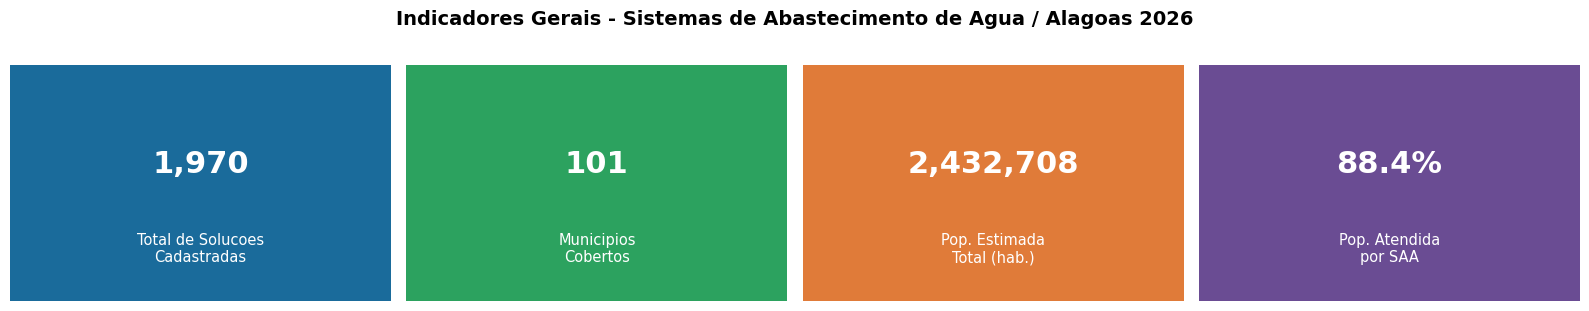

In [4]:
# @title Calculos do panorama geral
cont  = df['TP_ABASTECIMENTO'].value_counts().reindex(['SAA','SAC','SAI'])
pop_t = df.groupby('TP_ABASTECIMENTO')['POP'].sum().reindex(['SAA','SAC','SAI'])
pop_g = pop_t.sum()

# Cards
fig, axes = plt.subplots(1,4,figsize=(16,3))
fig.suptitle('Indicadores Gerais - Sistemas de Abastecimento de Agua / Alagoas 2026',
             fontsize=14, fontweight='bold', y=1.02)
cards = [
    (f'{len(df):,}',      'Total de Solucoes\nCadastradas',   '#1a6b9b'),
    (f'{df["NO_MUNICIPIO"].nunique()}', 'Municipios\nCobertos', '#2ca25f'),
    (f'{pop_g:,.0f}',    'Pop. Estimada\nTotal (hab.)',       '#e07b39'),
    (f'{pop_t["SAA"]/pop_g*100:.1f}%','Pop. Atendida\npor SAA','#6a4c93'),
]
for ax,(val,lab,cor) in zip(axes,cards):
    ax.set_facecolor(cor)
    ax.text(0.5,0.58,val,ha='center',va='center',fontsize=22,
            fontweight='bold',color='white',transform=ax.transAxes)
    ax.text(0.5,0.22,lab,ha='center',va='center',fontsize=10.5,
            color='white',transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)
plt.tight_layout()
plt.savefig('fig01_cards.png',dpi=150,bbox_inches='tight')
plt.show()

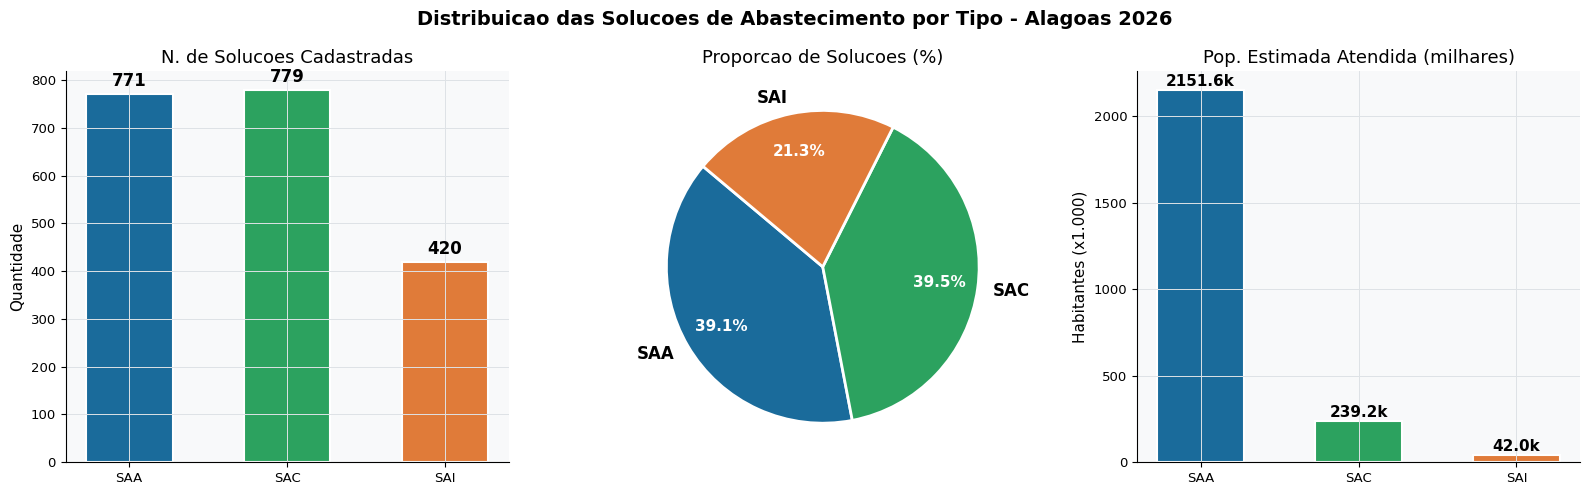

,Qtd. Solucoes,% Solucoes,Pop. Estimada,% Pop.
Tipo,,,,
SAA,771,39.1,2151581,88.4
SAC,779,39.5,239164,9.8
SAI,420,21.3,41963,1.7


In [5]:
# @title Grafico: distribuicao por tipo
# Distribuicao por tipo
fig, axes = plt.subplots(1,3,figsize=(16,5))
fig.suptitle('Distribuicao das Solucoes de Abastecimento por Tipo - Alagoas 2026',
             fontsize=14, fontweight='bold')

# Barras quantidade
ax = axes[0]
bars = ax.bar(cont.index, cont.values,
              color=[CORES_TIPO[t] for t in cont.index],
              edgecolor='white', linewidth=1.5, width=0.55)
for b,v in zip(bars,cont.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+8,
            f'{v:,}',ha='center',va='bottom',fontsize=12,fontweight='bold')
ax.set_title('N. de Solucoes Cadastradas')
ax.set_ylabel('Quantidade')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# Pizza
ax = axes[1]
wedges,texts,autotexts = ax.pie(
    cont.values, labels=cont.index,
    colors=[CORES_TIPO[t] for t in cont.index],
    autopct='%1.1f%%', startangle=140, pctdistance=0.75,
    wedgeprops={'edgecolor':'white','linewidth':2})
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight('bold'); at.set_color('white')
for t in texts: t.set_fontsize(12); t.set_fontweight('bold')
ax.set_title('Proporcao de Solucoes (%)')

# Populacao
ax = axes[2]
bars = ax.bar(pop_t.index, pop_t.values/1000,
              color=[CORES_TIPO[t] for t in pop_t.index],
              edgecolor='white', linewidth=1.5, width=0.55)
for b,v in zip(bars,pop_t.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+5,
            f'{v/1000:.1f}k',ha='center',va='bottom',fontsize=11,fontweight='bold')
ax.set_title('Pop. Estimada Atendida (milhares)')
ax.set_ylabel('Habitantes (x1.000)')

plt.tight_layout()
plt.savefig('fig02_tipo.png',dpi=150,bbox_inches='tight')
plt.show()

resumo_tipo = pd.DataFrame({
    'Tipo':cont.index,
    'Qtd. Solucoes':cont.values,
    '% Solucoes':(cont.values/cont.sum()*100).round(1),
    'Pop. Estimada':pop_t.values.astype(int),
    '% Pop.':(pop_t.values/pop_t.sum()*100).round(1),
}).set_index('Tipo')
resumo_tipo

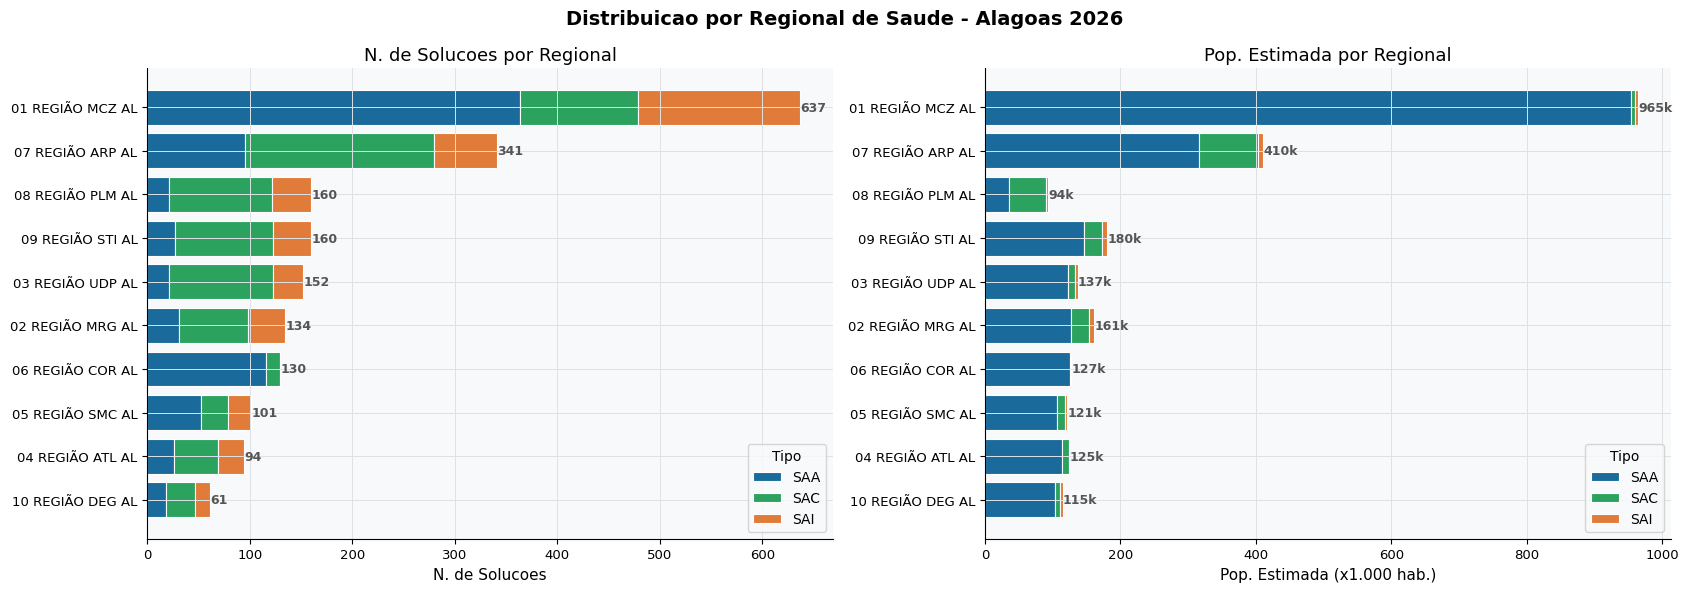

In [6]:
# @title Grafico: distribuicao por regional
# Por regional
tab_reg = df.groupby(['REGIONAL','TP_ABASTECIMENTO']).size()\
            .unstack(fill_value=0).reindex(columns=['SAA','SAC','SAI']).fillna(0)
tab_reg['Total'] = tab_reg.sum(axis=1)
tab_reg = tab_reg.sort_values('Total', ascending=True)

pop_reg = df.groupby(['REGIONAL','TP_ABASTECIMENTO'])['POP'].sum()\
            .unstack(fill_value=0).reindex(columns=['SAA','SAC','SAI']).fillna(0)
pop_reg = pop_reg.reindex(tab_reg.index).fillna(0)

fig, axes = plt.subplots(1,2,figsize=(17,6))
fig.suptitle('Distribuicao por Regional de Saude - Alagoas 2026',fontsize=14,fontweight='bold')

for ax, dados, label, div in [
    (axes[0], tab_reg, 'N. de Solucoes', 1),
    (axes[1], pop_reg, 'Pop. Estimada (x1.000 hab.)', 1000)
]:
    bottom = np.zeros(len(dados))
    for tipo in ['SAA','SAC','SAI']:
        vals = dados[tipo].values / div
        ax.barh(dados.index, vals, left=bottom,
                color=CORES_TIPO[tipo], label=tipo, edgecolor='white', linewidth=0.8)
        bottom += vals
    for i,(idx,row) in enumerate(dados.iterrows()):
        tot = row[['SAA','SAC','SAI']].sum() / div
        sufx = 'k' if div==1000 else ''
        ax.text(tot+0.5,i,f'{tot:.0f}{sufx}',va='center',fontsize=9,fontweight='bold',color='#555')
    ax.set_xlabel(label)
    ax.set_title(label.split('(')[0].strip() + ' por Regional')
    ax.legend(loc='lower right',title='Tipo')

plt.tight_layout()
plt.savefig('fig03_regional.png',dpi=150,bbox_inches='tight')
plt.show()

## 3. Cobertura Real - SISAGUA x IBGE 2022

O cruzamento entre a populacao estimada no SISAGUA e a populacao recenseada pelo IBGE 2022
permite calcular a **cobertura declarada** de cada municipio.

> Valores acima de 100% indicam possivel super-registro ou diferenca metodologica entre
> as bases (o IBGE usa populacao residente; o SISAGUA usa estimativa do prestador).

In [7]:
# @title Agregacao e calculo de cobertura municipal
# Agregar SISAGUA por municipio
agg = df.groupby('KEY').agg(
    MUNICIPIO=('NO_MUNICIPIO','first'),
    REGIONAL=('NO_REGIONAL','first'),
    N_TOTAL=('TP_ABASTECIMENTO','count'),
    N_SAA=('TP_ABASTECIMENTO', lambda x:(x=='SAA').sum()),
    N_SAC=('TP_ABASTECIMENTO', lambda x:(x=='SAC').sum()),
    N_SAI=('TP_ABASTECIMENTO', lambda x:(x=='SAI').sum()),
    POP_SISAGUA=('POP','sum'),
    POP_RURAL=('POP_RURAL','sum'),
    POP_URBAN=('POP_URBAN','sum'),
    N_DESINF=('DESINF','sum'),
    N_SUP=('SUP','sum'),
    ECON_TOTAL=('ECON_PERM','sum'),
).reset_index()

df_m = agg.merge(df_ibge[['KEY','MUNICIPIO_IBGE','POP_IBGE']], on='KEY', how='outer')
df_m['POP_SISAGUA'] = df_m['POP_SISAGUA'].fillna(0)
df_m['N_TOTAL']     = df_m['N_TOTAL'].fillna(0).astype(int)
df_m['MUNICIPIO']   = df_m['MUNICIPIO'].fillna(df_m['MUNICIPIO_IBGE'])

df_m['COB_PCT'] = (df_m['POP_SISAGUA']/df_m['POP_IBGE']*100).clip(upper=110)

def pct_desinf_saa_sac(key):
    sub = df[(df['KEY']==key) & (df['TP_ABASTECIMENTO'].isin(['SAA','SAC']))]
    return sub['DESINF'].mean()*100 if len(sub)>0 else 0

df_m['PCT_D'] = df_m['KEY'].apply(pct_desinf_saa_sac)

def score_mun(row):
    sub = df[(df['KEY']==row['KEY']) & (df['TP_ABASTECIMENTO'].isin(['SAA','SAC']))]
    if len(sub)==0: return 0
    pct_d = sub['DESINF'].mean()*100
    sub_s = sub[sub['SUP']==1]
    pct_f = sub_s['FILTR'].mean()*100 if len(sub_s)>0 else 0
    cob   = min(row['COB_PCT'], 100)
    return round(pct_d*0.6 + pct_f*0.2 + cob*0.2, 1)

df_m['SCORE'] = df_m.apply(score_mun, axis=1)

def classif_cob(v):
    if v>=80: return 'Adequada (>=80%)'
    if v>=50: return 'Parcial (50-79%)'
    if v>=20: return 'Insuficiente (20-49%)'
    if v>0:   return 'Critica (<20%)'
    return 'Sem registro'

def classif_qual(s):
    if s>=70: return 'Bom'
    if s>=40: return 'Regular'
    if s>=15: return 'Ruim'
    return 'Critico'

df_m['CLASSIF_COB']  = df_m['COB_PCT'].apply(classif_cob)
df_m['CLASSIF_QUAL'] = df_m['SCORE'].apply(classif_qual)

print(f'Municipios com dados SISAGUA : {(df_m["N_TOTAL"]>0).sum()}')
print(f'Sem qualquer registro        : {(df_m["N_TOTAL"]==0).sum()}')
print(f'Cobertura media estadual     : {df_m["COB_PCT"].mean():.1f}%')
df_m[['MUNICIPIO','POP_IBGE','POP_SISAGUA','COB_PCT','CLASSIF_COB','SCORE','CLASSIF_QUAL']]\
    .sort_values('COB_PCT',ascending=False).head(10)

Municipios com dados SISAGUA : 101
Sem qualquer registro        : 5
Cobertura media estadual     : 74.5%


,MUNICIPIO,POP_IBGE,POP_SISAGUA,COB_PCT,CLASSIF_COB,SCORE,CLASSIF_QUAL
22,COQUEIRO SECO,5579.0,6171.0,110.0,Adequada (>=80%),80.0,Bom
33,IGACI,23996.0,40594.0,110.0,Adequada (>=80%),25.1,Ruim
37,JACUIPE,5340.0,8250.0,110.0,Adequada (>=80%),45.5,Regular
26,DOIS RIACHOS,9754.0,12935.0,110.0,Adequada (>=80%),44.0,Regular
27,ESTRELA DE ALAGOAS,15322.0,18205.0,110.0,Adequada (>=80%),43.3,Regular
6,BATALHA,16016.0,31705.0,110.0,Adequada (>=80%),50.0,Regular
82,PORTO DE PEDRAS,9373.0,12232.0,110.0,Adequada (>=80%),50.0,Regular
93,SAO LUIS DO QUITUNDE,30922.0,41509.0,110.0,Adequada (>=80%),50.0,Regular
56,MINADOR DO NEGRAO,4838.0,6676.0,110.0,Adequada (>=80%),90.0,Bom
105,VICOSA,24089.0,32168.0,110.0,Adequada (>=80%),40.8,Regular


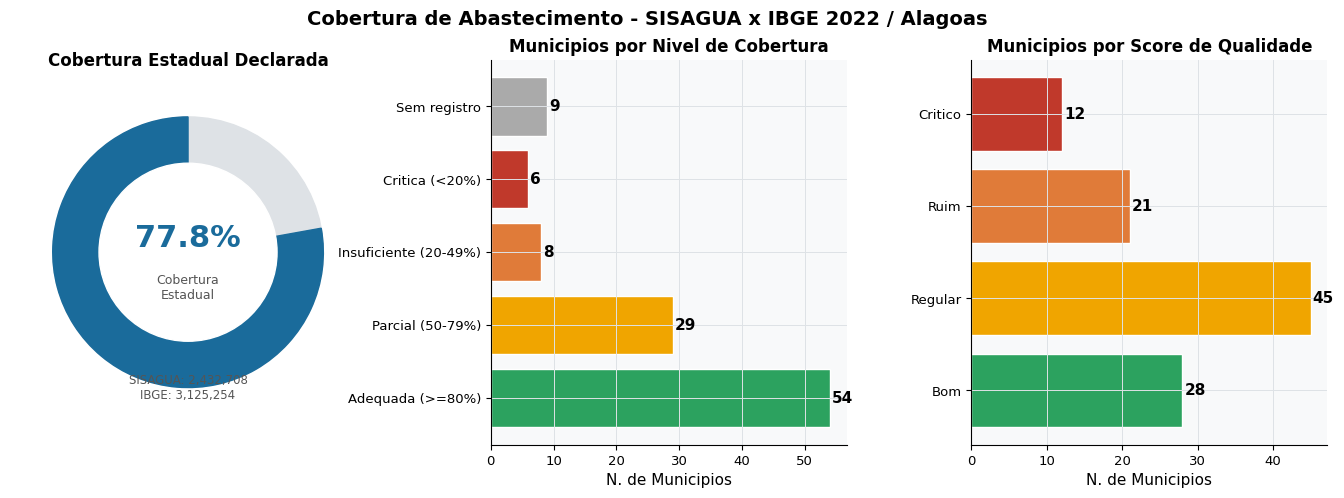

In [8]:
# @title Grafico: painel de cobertura estadual
# Painel cobertura
pop_ibge_t = df_m['POP_IBGE'].sum()
pop_sis_t  = df_m['POP_SISAGUA'].sum()
cob_est    = pop_sis_t/pop_ibge_t*100

ordem_cob = ['Adequada (>=80%)','Parcial (50-79%)','Insuficiente (20-49%)','Critica (<20%)','Sem registro']
ordem_qual= ['Bom','Regular','Ruim','Critico']
cores_qual= ['#2ca25f','#f0a500','#e07b39','#c0392b']
dist_cob  = df_m['CLASSIF_COB'].value_counts().reindex([o for o in ordem_cob if o in df_m['CLASSIF_COB'].unique()])
dist_qual = df_m['CLASSIF_QUAL'].value_counts()

fig = plt.figure(figsize=(17,5))
fig.suptitle('Cobertura de Abastecimento - SISAGUA x IBGE 2022 / Alagoas',
             fontsize=14, fontweight='bold')
gs = fig.add_gridspec(1,3,wspace=0.35)

# Donut
ax0 = fig.add_subplot(gs[0])
ax0.set_aspect('equal'); ax0.axis('off')
ax0.add_patch(plt.Circle((0.5,0.5),0.38,color='#dee2e6',transform=ax0.transAxes,zorder=1))
ax0.add_patch(plt.matplotlib.patches.Wedge(
    (0.5,0.5),0.38,90,90+360*cob_est/100,
    color='#1a6b9b',transform=ax0.transAxes,zorder=2))
ax0.add_patch(plt.Circle((0.5,0.5),0.25,color='white',transform=ax0.transAxes,zorder=3))
ax0.text(0.5,0.54,f'{cob_est:.1f}%',ha='center',va='center',fontsize=22,
         fontweight='bold',color='#1a6b9b',transform=ax0.transAxes,zorder=4)
ax0.text(0.5,0.40,'Cobertura\nEstadual',ha='center',va='center',fontsize=9,
         color='#555',transform=ax0.transAxes,zorder=4)
ax0.text(0.5,0.12,f'SISAGUA: {pop_sis_t:,.0f}\nIBGE: {pop_ibge_t:,.0f}',
         ha='center',va='center',fontsize=8.5,color='#555',transform=ax0.transAxes)
ax0.set_title('Cobertura Estadual Declarada',fontsize=12,fontweight='bold')

# Classificacao cobertura
ax1 = fig.add_subplot(gs[1])
cores_b = [CORES_COB.get(c,'#aaa') for c in dist_cob.index]
bars = ax1.barh(dist_cob.index, dist_cob.values, color=cores_b, edgecolor='white')
for b,v in zip(bars,dist_cob.values):
    ax1.text(b.get_width()+0.3,b.get_y()+b.get_height()/2,
             str(v),va='center',fontsize=11,fontweight='bold')
ax1.set_xlabel('N. de Municipios')
ax1.set_title('Municipios por Nivel de Cobertura',fontsize=12,fontweight='bold')

# Score
ax2 = fig.add_subplot(gs[2])
vals_q = [dist_qual.get(o,0) for o in ordem_qual]
bars2 = ax2.barh(ordem_qual, vals_q, color=cores_qual, edgecolor='white')
for b,v in zip(bars2,vals_q):
    ax2.text(b.get_width()+0.3,b.get_y()+b.get_height()/2,
             str(v),va='center',fontsize=11,fontweight='bold')
ax2.set_xlabel('N. de Municipios')
ax2.set_title('Municipios por Score de Qualidade',fontsize=12,fontweight='bold')

plt.savefig('fig04_cobertura_geral.png',dpi=150,bbox_inches='tight')
plt.show()

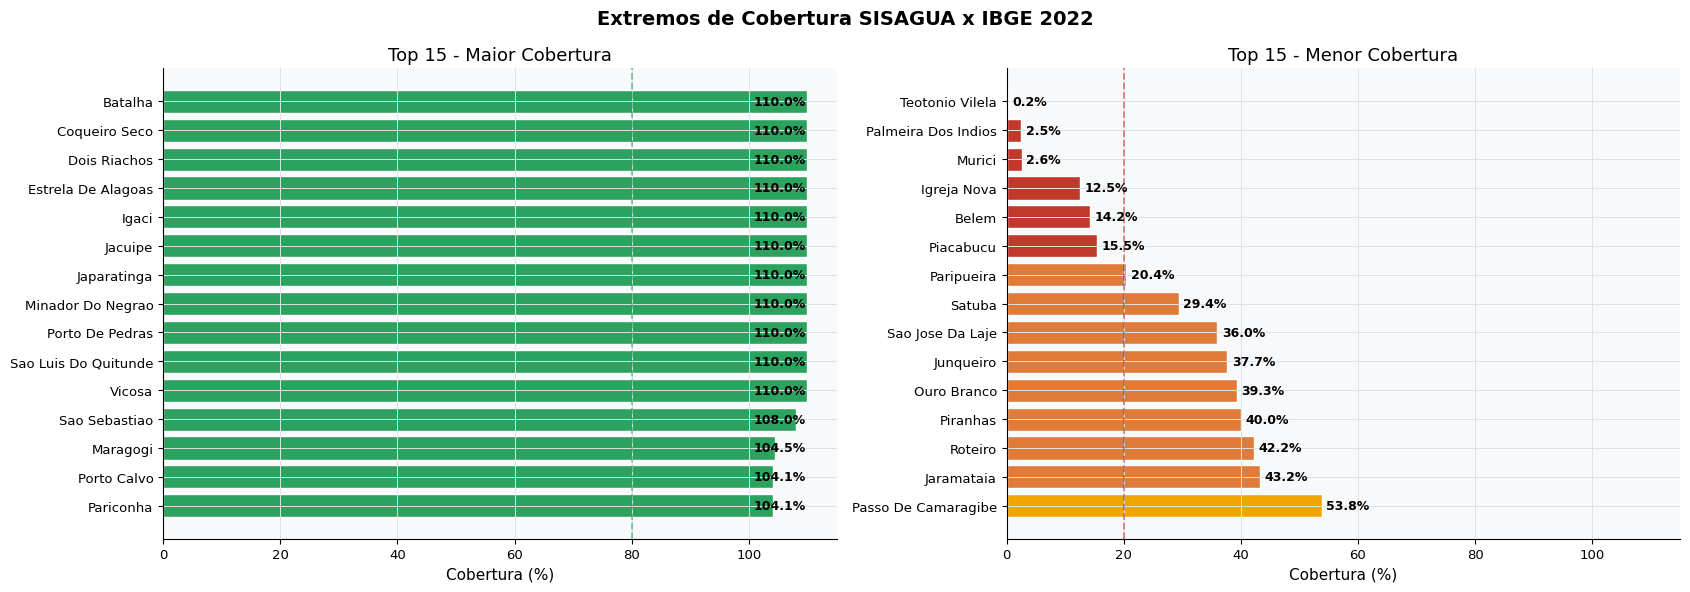

In [9]:
# @title Grafico: extremos de cobertura
# Extremos de cobertura
df_p   = df_m[df_m['POP_IBGE']>0].copy()
top15  = df_p.nlargest(15,'COB_PCT')
bot15  = df_p[df_p['COB_PCT']>0].nsmallest(15,'COB_PCT')

fig, axes = plt.subplots(1,2,figsize=(17,6))
fig.suptitle('Extremos de Cobertura SISAGUA x IBGE 2022',fontsize=14,fontweight='bold')

for ax,dados,titulo,linha,cor_l in [
    (axes[0],top15,'Top 15 - Maior Cobertura',80,'#2ca25f'),
    (axes[1],bot15,'Top 15 - Menor Cobertura',20,'#c0392b'),
]:
    cores_b = [cor_cob(v) for v in dados['COB_PCT'].values[::-1]]
    bars = ax.barh(dados['MUNICIPIO'].str.title().values[::-1],
                   dados['COB_PCT'].values[::-1], color=cores_b, edgecolor='white')
    for b,v in zip(bars,dados['COB_PCT'].values[::-1]):
        ax.text(min(v,100)+0.8,b.get_y()+b.get_height()/2,
                f'{v:.1f}%',va='center',fontsize=9,fontweight='bold')
    ax.axvline(linha,color=cor_l,linestyle='--',alpha=0.6,linewidth=1.3)
    ax.set_xlim(0,115); ax.set_xlabel('Cobertura (%)'); ax.set_title(titulo)

plt.tight_layout()
plt.savefig('fig05_extremos_cob.png',dpi=150,bbox_inches='tight')
plt.show()

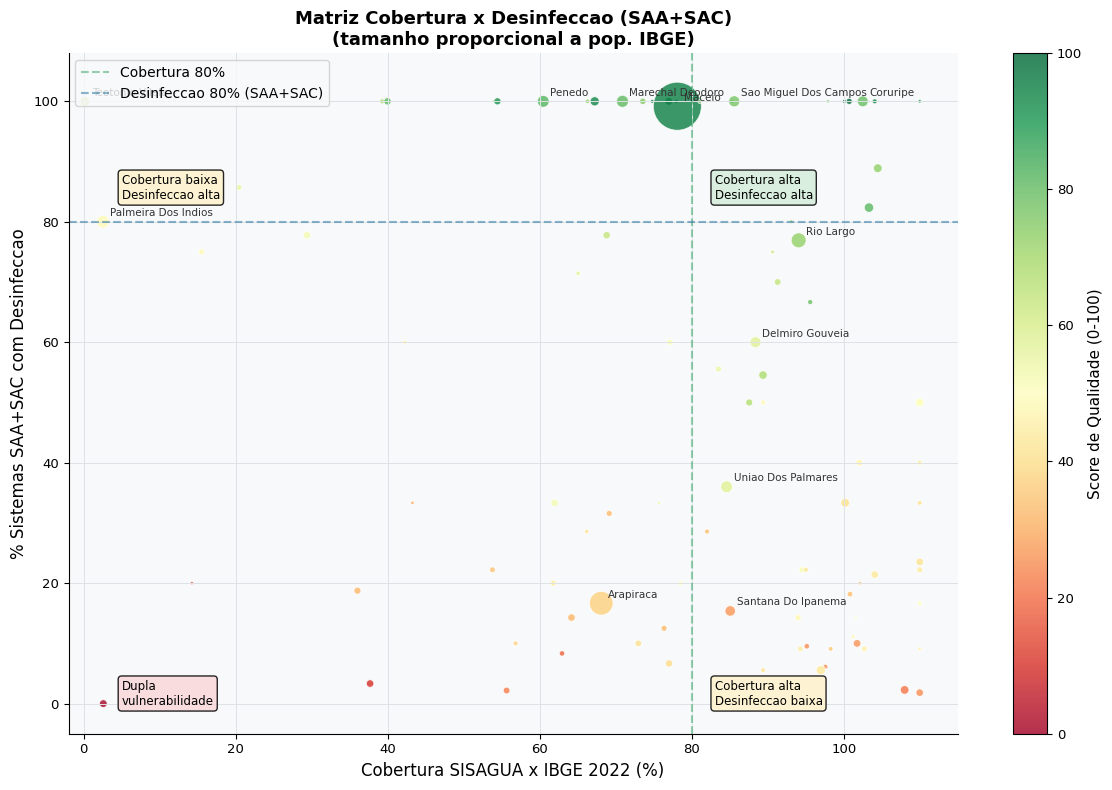

In [10]:
# @title Grafico: matriz cobertura x desinfeccao
# Matriz Cobertura x Desinfeccao SAA+SAC
df_mx = df_m[df_m['N_TOTAL']>0].copy()

fig, ax = plt.subplots(figsize=(12,8))
sc = ax.scatter(
    df_mx['COB_PCT'], df_mx['PCT_D'],
    s=df_mx['POP_IBGE']/800, c=df_mx['SCORE'],
    cmap='RdYlGn', alpha=0.8, edgecolors='white', linewidths=0.7,
    vmin=0, vmax=100)
plt.colorbar(sc, ax=ax, label='Score de Qualidade (0-100)')
ax.axvline(80,color='#2ca25f',linestyle='--',alpha=0.5,linewidth=1.5,label='Cobertura 80%')
ax.axhline(80,color='#1a6b9b',linestyle='--',alpha=0.5,linewidth=1.5,label='Desinfeccao 80% (SAA+SAC)')

for txt,x,y,cor in [
    ('Cobertura alta\nDesinfeccao alta',83,88,'#d4edda'),
    ('Cobertura baixa\nDesinfeccao alta',5,88,'#fff3cd'),
    ('Cobertura alta\nDesinfeccao baixa',83,4,'#fff3cd'),
    ('Dupla\nvulnerabilidade',5,4,'#f8d7da'),
]:
    ax.text(x,y,txt,fontsize=8.5,va='top',
            bbox=dict(boxstyle='round,pad=0.3',facecolor=cor,alpha=0.85))

for _,r in df_mx.nlargest(12,'POP_IBGE').iterrows():
    ax.annotate(r['MUNICIPIO'].title(),
                xy=(r['COB_PCT'],r['PCT_D']),
                xytext=(5,4),textcoords='offset points',fontsize=7.5,color='#333')

ax.set_xlabel('Cobertura SISAGUA x IBGE 2022 (%)',fontsize=12)
ax.set_ylabel('% Sistemas SAA+SAC com Desinfeccao',fontsize=12)
ax.set_title('Matriz Cobertura x Desinfeccao (SAA+SAC)\n(tamanho proporcional a pop. IBGE)',
             fontsize=13, fontweight='bold')
ax.set_xlim(-2,115); ax.set_ylim(-5,108)
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('fig06_matriz.png',dpi=150,bbox_inches='tight')
plt.show()

## 4. Qualidade da Infraestrutura - Desinfeccao e Filtracao

### Base normativa - Portaria GM/MS n. 888/2021

- **Art. 5** - Define SAA, SAC e SAI e seus criterios de classificacao.
- **Art. 39** - O responsavel pelo SAA e pelo SAC deve garantir que a agua fornecida
  atenda aos padroes de potabilidade.
- **Art. 40** - A desinfeccao e **obrigatoria** em todo SAA e SAC que utilize
  manancial superficial ou subterraneo com historico de contaminacao microbiologica.
- **Anexo XX** - Define Cloro Residual Livre (min. 0,2 mg/L) e Turbidez como
  parametros minimos de controle.

> **Nota - filtracao:** Analisada apenas em SAA e SAC com captacao superficial.
> Captacao subterranea sera incluida apos cruzamento com amostras laboratoriais do SISAGUA.

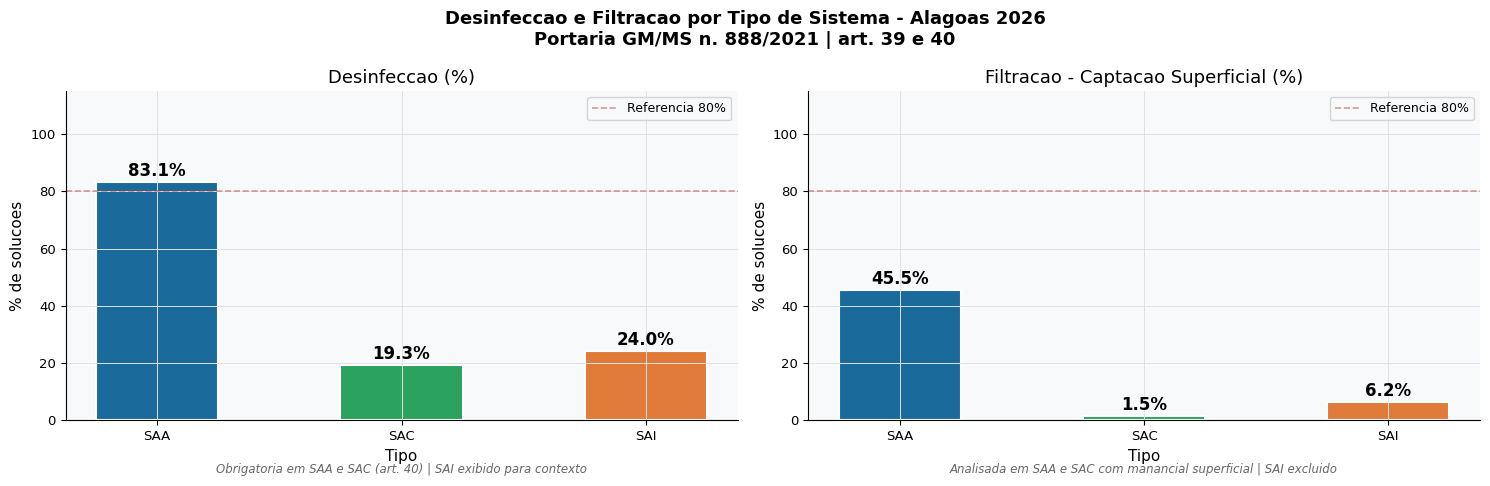

,N Sistemas,% Desinfeccao,% Filtracao (sup.),% Capt. Superficial,% Capt. Subterranea
Tipo,,,,,
SAA,771,83.1,45.5,24.3,78.2
SAC,779,19.3,1.5,8.7,90.8
SAI,420,24.0,6.2,7.6,83.6


In [11]:
# @title Grafico: desinfeccao e filtracao por tipo
tipos = ['SAA','SAC','SAI']
pcts_desinf, pcts_filtr_sup = [], []
for t in tipos:
    sub = df[df['TP_ABASTECIMENTO']==t]
    pcts_desinf.append(sub['DESINF'].mean()*100)
    sub_sup = sub[sub['SUP']==1]
    pcts_filtr_sup.append(sub_sup['FILTR'].mean()*100 if len(sub_sup)>0 else 0)

fig, axes = plt.subplots(1,2,figsize=(15,5))
fig.suptitle('Desinfeccao e Filtracao por Tipo de Sistema - Alagoas 2026\n'
             'Portaria GM/MS n. 888/2021 | art. 39 e 40',
             fontsize=13, fontweight='bold')

for ax,pcts,titulo,nota in [
    (axes[0], pcts_desinf, 'Desinfeccao (%)',
     'Obrigatoria em SAA e SAC (art. 40) | SAI exibido para contexto'),
    (axes[1], pcts_filtr_sup, 'Filtracao - Captacao Superficial (%)',
     'Analisada em SAA e SAC com manancial superficial | SAI excluido'),
]:
    bars = ax.bar(tipos, pcts,
                  color=[CORES_TIPO[t] for t in tipos],
                  edgecolor='white', linewidth=1.5, width=0.5)
    for b,v in zip(bars,pcts):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.8,
                f'{v:.1f}%',ha='center',va='bottom',fontsize=12,fontweight='bold')
    ax.set_ylim(0,115)
    ax.axhline(80,color='#c0392b',linestyle='--',alpha=0.5,linewidth=1.2,label='Referencia 80%')
    ax.set_ylabel('% de solucoes'); ax.set_title(titulo); ax.set_xlabel('Tipo')
    ax.legend(fontsize=9)
    ax.text(0.5,-0.16,nota,ha='center',transform=ax.transAxes,fontsize=8.5,color='#666',style='italic')

plt.tight_layout()
plt.savefig('fig07_desinf_filtr.png',dpi=150,bbox_inches='tight')
plt.show()

# Tabela
tbl = []
for t in tipos:
    sub = df[df['TP_ABASTECIMENTO']==t]
    sub_sup = sub[sub['SUP']==1]
    tbl.append({
        'Tipo':t, 'N Sistemas':len(sub),
        '% Desinfeccao':f"{sub['DESINF'].mean()*100:.1f}",
        '% Filtracao (sup.)':f"{sub_sup['FILTR'].mean()*100:.1f}" if len(sub_sup)>0 else '-',
        '% Capt. Superficial':f"{sub['SUP'].mean()*100:.1f}",
        '% Capt. Subterranea':f"{sub['SUB'].mean()*100:.1f}",
    })
pd.DataFrame(tbl).set_index('Tipo')

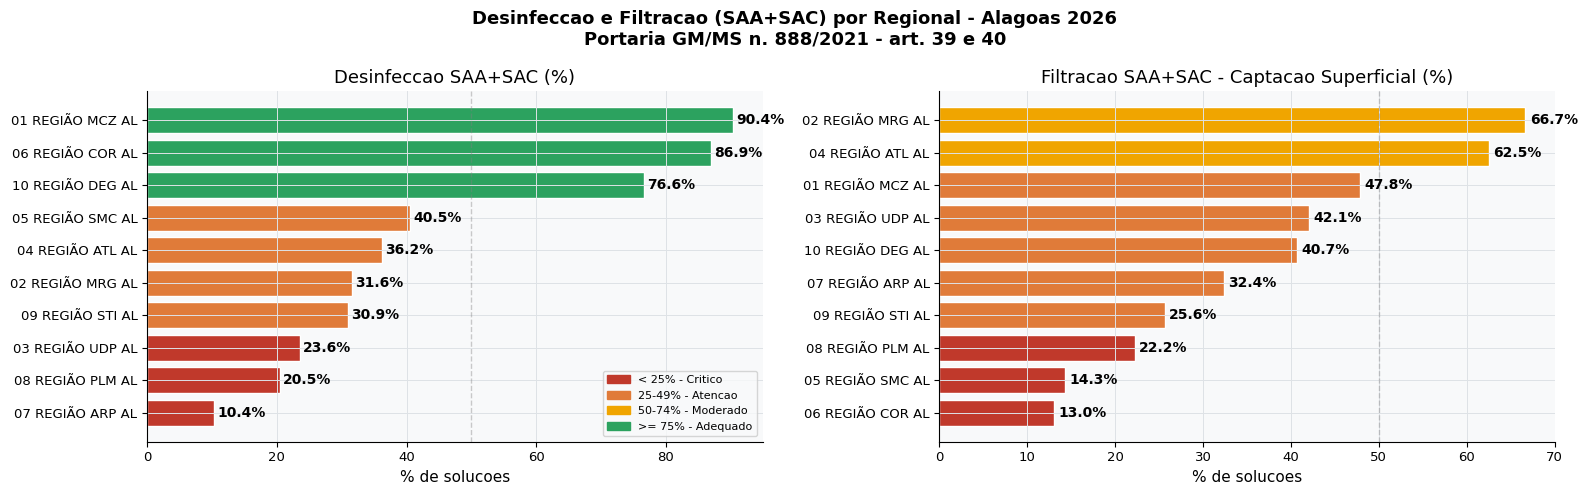

In [12]:
# @title Grafico: desinfeccao e filtracao por regional
# Desinfeccao e Filtracao SAA+SAC por Regional
base_saa_sac = df[df['TP_ABASTECIMENTO'].isin(['SAA','SAC'])]

reg_d = base_saa_sac.groupby('REGIONAL')\
                    .apply(lambda x: x['DESINF'].mean()*100).sort_values()

base_sup = df[(df['TP_ABASTECIMENTO'].isin(['SAA','SAC'])) & (df['SUP']==1)]
reg_f = base_sup.groupby('REGIONAL')\
                .apply(lambda x: x['FILTR'].mean()*100).sort_values()

fig, axes = plt.subplots(1,2,figsize=(16,5))
fig.suptitle('Desinfeccao e Filtracao (SAA+SAC) por Regional - Alagoas 2026\n'
             'Portaria GM/MS n. 888/2021 - art. 39 e 40',
             fontsize=13, fontweight='bold')

for ax,dados,titulo in [
    (axes[0],reg_d,'Desinfeccao SAA+SAC (%)'),
    (axes[1],reg_f,'Filtracao SAA+SAC - Captacao Superficial (%)'),
]:
    cores_b = [('#c0392b' if v<25 else '#e07b39' if v<50 else '#f0a500' if v<75 else '#2ca25f')
               for v in dados.values]
    bars = ax.barh(dados.index, dados.values, color=cores_b, edgecolor='white')
    for b,v in zip(bars,dados.values):
        ax.text(b.get_width()+0.5,b.get_y()+b.get_height()/2,
                f'{v:.1f}%',va='center',fontsize=10,fontweight='bold')
    ax.axvline(50,color='gray',linestyle='--',alpha=0.4,linewidth=1)
    ax.set_xlabel('% de solucoes'); ax.set_title(titulo)

patches = [
    mpatches.Patch(color='#c0392b',label='< 25% - Critico'),
    mpatches.Patch(color='#e07b39',label='25-49% - Atencao'),
    mpatches.Patch(color='#f0a500',label='50-74% - Moderado'),
    mpatches.Patch(color='#2ca25f',label='>= 75% - Adequado'),
]
axes[0].legend(handles=patches,loc='lower right',fontsize=8)
plt.tight_layout()
plt.savefig('fig08_desinf_regional.png',dpi=150,bbox_inches='tight')
plt.show()

## 5. Auditoria Cadastral - Anomalias Identificadas

### 5.1 SAI com mais de 10 economias

A **Portaria GM/MS n. 888/2021 (art. 5)** define a SAI como solucao que atende
a **um unico domicilio**. Um sistema com mais de 10 economias permanentes nao
se enquadra nessa definicao — caracteriza atendimento coletivo e deve ser
recadastrado como **SAC**.

A presenca de desinfeccao e/ou filtracao nesses sistemas reforca o diagnostico:
infraestrutura de tratamento coletivo e incompativel com a classificacao individual,
mas ressalta-se que **a existencia de tratamento em um SAI nao e, por si so,
uma anomalia** — e uma boa pratica. O equivoco e a classificacao como SAI
quando o sistema atende multiplos domicilios.

In [13]:
# @title Identificacao dos SAI anomalos
sai_anomalo = df[
    (df['TP_ABASTECIMENTO']=='SAI') &
    (df['ECON_PERM'] > 10)
][['NO_MUNICIPIO','NO_SOLUCAO_ABASTECIMENTO','ECON_PERM',
   'POP','DESINF','FILTR','SUP','SUB']]\
    .sort_values('ECON_PERM', ascending=False).copy()

sai_anomalo['TEM_TRAT'] = sai_anomalo.apply(
    lambda r: 'Sim' if r['DESINF']==1 or r['FILTR']==1 else 'Nao', axis=1)

print(f'SAI com > 10 economias permanentes : {len(sai_anomalo)}')
print(f'Desses, com desinfeccao ou filtracao: {(sai_anomalo["TEM_TRAT"]=="Sim").sum()}')
print()
print('Referencia: Portaria GM/MS 888/2021, art. 5 - SAI atende um unico domicilio.')
print()
sai_anomalo[['NO_MUNICIPIO','NO_SOLUCAO_ABASTECIMENTO',
             'ECON_PERM','POP','TEM_TRAT']].rename(columns={
    'NO_MUNICIPIO':'Municipio','NO_SOLUCAO_ABASTECIMENTO':'Sistema',
    'ECON_PERM':'Economias','POP':'Pop. Estimada','TEM_TRAT':'Tem Tratamento?'
})

SAI com > 10 economias permanentes : 136
Desses, com desinfeccao ou filtracao: 24

Referencia: Portaria GM/MS 888/2021, art. 5 - SAI atende um unico domicilio.



,Municipio,Sistema,Economias,Pop. Estimada,Tem Tratamento?
1730,AGUA BRANCA,SAI DE AGUA BRANCA GRUPO DE CISTERNAS DE PLACA,999.0,3327.0,Nao
1848,OLIVENCA,SAI DE OLIVENCA BOM SUCESSO,685.0,2069.0,Nao
1693,SAO SEBASTIAO,SAI DE SAO SEBASTIAO BELISCA PAU,630.0,1903.0,Nao
1641,SAO SEBASTIAO,SAI DE SAO SEBASTIAO SITIO LAGOA SECA,450.0,1359.0,Nao
1675,ROTEIRO,SAI DE ROTEIRO BAIXADA DA CAMBOA,350.0,1141.0,Nao
...,...,...,...,...,...
1724,FLEXEIRAS,SAI DE FLEXEIRAS GRUPO FAZENDA INDEPENDENCIA,13.0,40.0,Sim
1758,BELEM,SAI DE BELEM GRUPO VARZEA DO ARROZ,13.0,37.0,Nao
1778,SANTANA DO MUNDAU,SAI FAZENDA PENHA,12.0,36.0,Nao
1638,FLEXEIRAS,SAI DE FLEXEIRAS ZONA URBANA,11.0,34.0,Nao


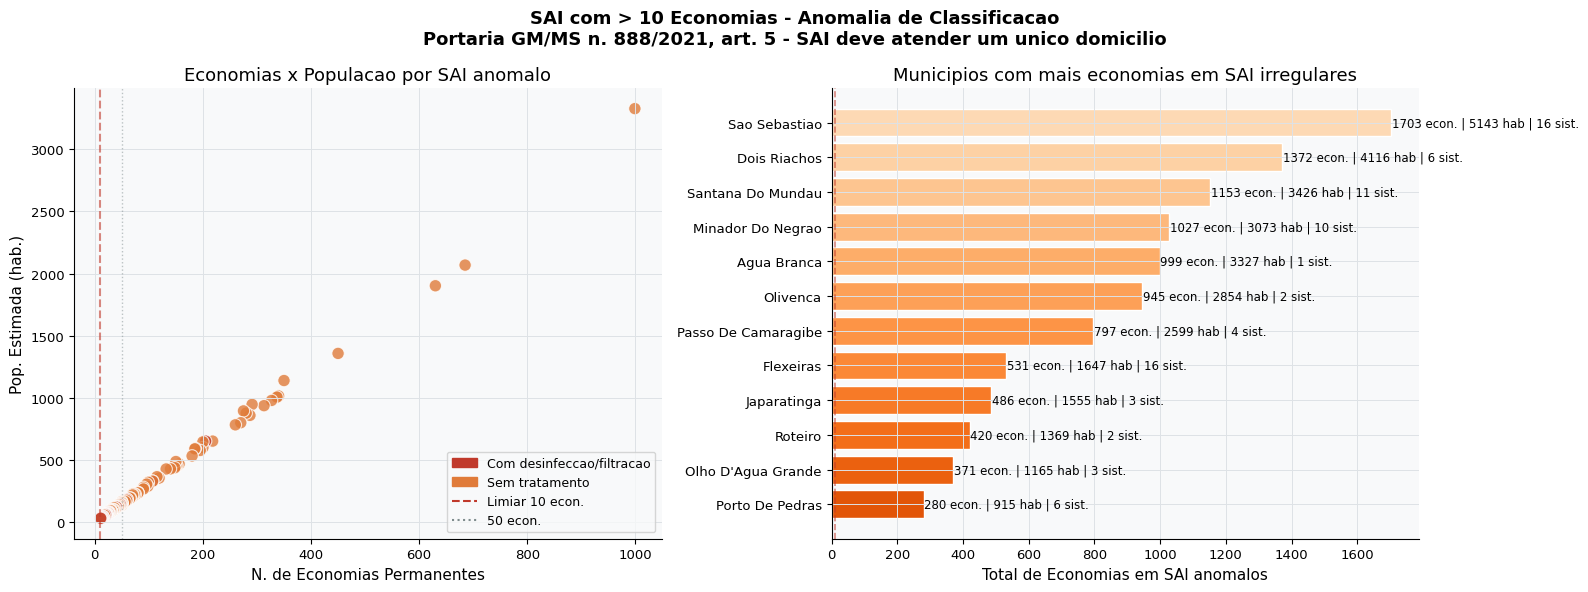

In [14]:
# @title Grafico: SAI com mais de 10 economias
fig, axes = plt.subplots(1,2,figsize=(16,6))
fig.suptitle('SAI com > 10 Economias - Anomalia de Classificacao\n'
             'Portaria GM/MS n. 888/2021, art. 5 - SAI deve atender um unico domicilio',
             fontsize=13, fontweight='bold')

# Scatter economias x pop
ax = axes[0]
cores_trat = ['#c0392b' if t=='Sim' else '#e07b39' for t in sai_anomalo['TEM_TRAT']]
ax.scatter(sai_anomalo['ECON_PERM'], sai_anomalo['POP'],
           c=cores_trat, s=80, alpha=0.8, edgecolors='white', linewidths=0.8)
ax.axvline(10,color='#c0392b',linestyle='--',alpha=0.6,linewidth=1.5,label='Limiar 10 economias')
ax.axvline(50,color='#7f8c8d',linestyle=':',alpha=0.5,linewidth=1,label='50 economias')
ax.set_xlabel('N. de Economias Permanentes')
ax.set_ylabel('Pop. Estimada (hab.)')
ax.set_title('Economias x Populacao por SAI anomalo')
patches_c = [
    mpatches.Patch(color='#c0392b',label='Com desinfeccao/filtracao'),
    mpatches.Patch(color='#e07b39',label='Sem tratamento'),
    plt.Line2D([0],[0],color='#c0392b',linestyle='--',label='Limiar 10 econ.'),
    plt.Line2D([0],[0],color='#7f8c8d',linestyle=':',label='50 econ.'),
]
ax.legend(handles=patches_c,fontsize=9)

# Top municipios
ax = axes[1]
top_mun = sai_anomalo.groupby('NO_MUNICIPIO').agg(
    N=('ECON_PERM','count'),
    ECON_TOT=('ECON_PERM','sum'),
    POP_TOT=('POP','sum'),
    N_TRAT=('DESINF',lambda x:(x==1).sum())
).sort_values('ECON_TOT',ascending=True).tail(12)
cores_m = plt.cm.Oranges_r(np.linspace(0.3,0.8,len(top_mun)))
bars = ax.barh(top_mun.index.str.title(), top_mun['ECON_TOT'], color=cores_m, edgecolor='white')
for b,(idx,row) in zip(bars,top_mun.iterrows()):
    ax.text(b.get_width()+2,b.get_y()+b.get_height()/2,
            f"{int(row['ECON_TOT'])} econ. | {int(row['POP_TOT'])} hab | {int(row['N'])} sist.",
            va='center',fontsize=8.5)
ax.axvline(10,color='#c0392b',linestyle='--',alpha=0.6,linewidth=1.2)
ax.set_xlabel('Total de Economias em SAI anomalos')
ax.set_title('Municipios com mais economias em SAI irregulares')

plt.tight_layout()
plt.savefig('fig09_sai_anomalo.png',dpi=150,bbox_inches='tight')
plt.show()

### 5.2 Outras Anomalias Cadastrais

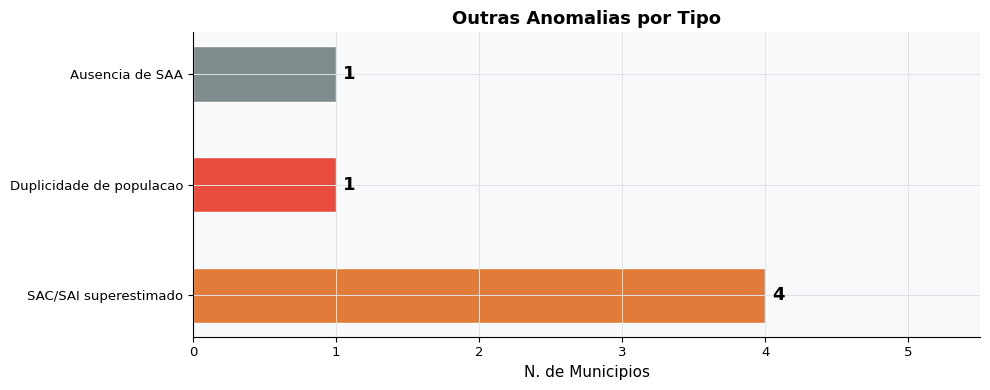

,Municipio,Tipo de Erro,Sistema Suspeito,Acao Recomendada
0,BATALHA,SAC/SAI superestimado,SAC VEICULO TRANSPORTADOR,Corrigir pop.: recalcular com econ. permanente...
1,ESTRELA DE ALAGOAS,SAC/SAI superestimado,SAC Carro-Pipa + Sistemas Solares,Verificar se SAC de carro-pipa e sistemas sola...
2,ANADIA,SAC/SAI superestimado,Varios SAC com POP_URBANA > 0,Verificar se SAC urbanos de Anadia sobrepoem a...
3,BELEM,SAC/SAI superestimado,SAA com econ. nao permanente = 2.150,Revisar campo econ. nao permanentes. Verificar...
4,POCO DAS TRINCHEIRAS,Duplicidade de populacao,SAC Bicudo SEMARH + SAC Sitio Barro Vermelho,Revisar e corrigir economias e pop. dos dois S...
5,MURICI,Ausencia de SAA,Nenhum SAA cadastrado,Acionar prestador para cadastro imediato do SA...


In [15]:
# @title Outras anomalias cadastrais
outras = [
    {'MUNICIPIO':'BATALHA','TIPO_ERRO':'SAC/SAI superestimado',
     'SISTEMA':'SAC VEICULO TRANSPORTADOR',
     'EVIDENCIA':'Pop. (16.448 hab) preenchida com econ. nao permanentes em vez da estimativa real.',
     'ACAO':'Corrigir pop.: recalcular com econ. permanentes x fator hab/econ.'},
    {'MUNICIPIO':'ESTRELA DE ALAGOAS','TIPO_ERRO':'SAC/SAI superestimado',
     'SISTEMA':'SAC Carro-Pipa + Sistemas Solares',
     'EVIDENCIA':'Soma SAA+SAC ultrapassa pop. IBGE (15.322 hab). Possivel contagem dupla.',
     'ACAO':'Verificar se SAC de carro-pipa e sistemas solares atendem populacoes distintas.'},
    {'MUNICIPIO':'ANADIA','TIPO_ERRO':'SAC/SAI superestimado',
     'SISTEMA':'Varios SAC com POP_URBANA > 0',
     'EVIDENCIA':'SAC com zona urbana preenchida - atipico; SAC normalmente atende zona rural.',
     'ACAO':'Verificar se SAC urbanos de Anadia sobrepoem area coberta pelo SAA.'},
    {'MUNICIPIO':'BELEM','TIPO_ERRO':'SAC/SAI superestimado',
     'SISTEMA':'SAA com econ. nao permanente = 2.150',
     'EVIDENCIA':'Campo NU_ECONOMIAS_DOMICILIOS_NAO_PE=2.150 em todos os SAA. Possivel erro de digitacao.',
     'ACAO':'Revisar campo econ. nao permanentes. Verificar numero real de economias permanentes.'},
    {'MUNICIPIO':'POCO DAS TRINCHEIRAS','TIPO_ERRO':'Duplicidade de populacao',
     'SISTEMA':'SAC Bicudo SEMARH + SAC Sitio Barro Vermelho',
     'EVIDENCIA':'Dois SAC com 1.283 econ./3.952 hab identicos ao SAA. Triplicidade de pop.',
     'ACAO':'Revisar e corrigir economias e pop. dos dois SAC com valores duplicados do SAA.'},
    {'MUNICIPIO':'MURICI','TIPO_ERRO':'Ausencia de SAA',
     'SISTEMA':'Nenhum SAA cadastrado',
     'EVIDENCIA':'Apenas 2 SAC (650 hab) para 25.221 habitantes (IBGE 2022).',
     'ACAO':'Acionar prestador para cadastro imediato do SAA de Murici no SISAGUA.'},
]
df_outras = pd.DataFrame(outras)

# Grafico
cont_tipo = df_outras['TIPO_ERRO'].value_counts()
fig, ax = plt.subplots(figsize=(10,4))
cores_o = [CORES_ERR.get(t,'#aaa') for t in cont_tipo.index]
bars = ax.barh(cont_tipo.index, cont_tipo.values, color=cores_o, edgecolor='white', height=0.5)
for b,v in zip(bars,cont_tipo.values):
    ax.text(b.get_width()+0.05,b.get_y()+b.get_height()/2,
            str(v),va='center',fontsize=13,fontweight='bold')
ax.set_xlabel('N. de Municipios')
ax.set_title('Outras Anomalias por Tipo',fontsize=13,fontweight='bold')
ax.set_xlim(0,cont_tipo.max()+1.5)
plt.tight_layout()
plt.savefig('fig10_outras_anomalias.png',dpi=150,bbox_inches='tight')
plt.show()

df_outras[['MUNICIPIO','TIPO_ERRO','SISTEMA','ACAO']].rename(columns={
    'MUNICIPIO':'Municipio','TIPO_ERRO':'Tipo de Erro',
    'SISTEMA':'Sistema Suspeito','ACAO':'Acao Recomendada'
})

In [16]:
# @title Exportacao: tabela de notificacao CSV
# Exportar tabela de notificacao
notif_sai = sai_anomalo[['NO_MUNICIPIO','NO_SOLUCAO_ABASTECIMENTO','ECON_PERM','POP','TEM_TRAT']]\
    .rename(columns={'NO_MUNICIPIO':'MUNICIPIO','NO_SOLUCAO_ABASTECIMENTO':'SISTEMA',
                     'ECON_PERM':'ECONOMIAS','POP':'POP_ESTIMADA','TEM_TRAT':'TEM_TRATAMENTO'})\
    .assign(TIPO_ERRO='SAI com > 10 economias',
            ACAO='Verificar classificacao: reclassificar como SAC se atendimento for coletivo.')

notif_outras = df_outras.rename(columns={'MUNICIPIO':'MUNICIPIO','SISTEMA':'SISTEMA'})\
    [['MUNICIPIO','TIPO_ERRO','SISTEMA','ACAO']]\
    .assign(ECONOMIAS=None,POP_ESTIMADA=None,TEM_TRATAMENTO=None)

notif_final = pd.concat([notif_sai, notif_outras], ignore_index=True)
notif_final.to_csv('notificacao_anomalias_SISAGUA_AL.csv', encoding='utf-8-sig', index=False)
print(f'Arquivo exportado: notificacao_anomalias_SISAGUA_AL.csv')
print(f'Total de registros: {len(notif_final)}')

Arquivo exportado: notificacao_anomalias_SISAGUA_AL.csv
Total de registros: 142


## 6. Sintese Executiva e Recomendacoes

## 6. Listagem para Intervencao — SAA/SAC sem Desinfeccao e SAI com > 10 Economias

Esta secao apresenta os sistemas individualizados que demandam acao imediata,
organizados por tipo de pendencia. Os arquivos CSV gerados podem ser encaminhados
diretamente aos prestadores de servico e equipes de vigilancia municipal.

**Referencia normativa — Portaria GM/MS n. 888/2021:**
- Art. 40: Desinfeccao e obrigatoria em SAA e SAC que utilizem manancial
  superficial ou subterraneo com historico de contaminacao microbiologica.
- Art. 5: SAI deve atender a um unico domicilio. Sistemas com > 10 economias
  caracterizam atendimento coletivo e devem ser recadastrados como SAC.

### 6.1 SAA e SAC sem Desinfeccao

In [17]:
# @title Listagem SAA e SAC sem desinfeccao
# SAA e SAC sem desinfeccao
sem_desinf = df[
    (df['TP_ABASTECIMENTO'].isin(['SAA','SAC'])) &
    (df['DESINF'] == 0)
][[
    'NO_MUNICIPIO','REGIONAL','TP_ABASTECIMENTO',
    'NO_SOLUCAO_ABASTECIMENTO','SG_EMPRESA','NO_EMPRESA',
    'ECON_PERM','POP','SUP','SUB',
    'FILTRACAO','DT_FORMULARIO_CADASTRO'
]].copy()

sem_desinf['CAPTACAO'] = sem_desinf.apply(
    lambda r: 'Superficial' if r['SUP']==1
    else ('Subterranea' if r['SUB']==1 else 'Nao informada'), axis=1)

sem_desinf = sem_desinf.drop(columns=['SUP','SUB'])\
    .rename(columns={
        'NO_MUNICIPIO':'Municipio','REGIONAL':'Regional',
        'TP_ABASTECIMENTO':'Tipo','NO_SOLUCAO_ABASTECIMENTO':'Sistema',
        'SG_EMPRESA':'Sigla Empresa','NO_EMPRESA':'Empresa',
        'ECON_PERM':'Economias','POP':'Pop. Estimada',
        'CAPTACAO':'Captacao','FILTRACAO':'Filtracao',
        'DT_FORMULARIO_CADASTRO':'Dt. Cadastro'
    })\
    .sort_values(['Regional','Municipio','Tipo','Pop. Estimada'],
                 ascending=[True,True,True,False])\
    .reset_index(drop=True)

sem_desinf.index += 1

total_saa_sd = (sem_desinf['Tipo']=='SAA').sum()
total_sac_sd = (sem_desinf['Tipo']=='SAC').sum()
pop_sd = sem_desinf['Pop. Estimada'].sum()

print(f'Sistemas SAA sem desinfeccao : {total_saa_sd}')
print(f'Sistemas SAC sem desinfeccao : {total_sac_sd}')
print(f'Total                        : {total_saa_sd + total_sac_sd}')
print(f'Pop. estimada afetada        : {pop_sd:,.0f} hab.')
print()
print('Referencia: Portaria GM/MS 888/2021, art. 40')
sem_desinf.head(20)

Sistemas SAA sem desinfeccao : 130
Sistemas SAC sem desinfeccao : 629
Total                        : 759
Pop. estimada afetada        : 269,605 hab.

Referencia: Portaria GM/MS 888/2021, art. 40


,Municipio,Regional,Tipo,Sistema,Sigla Empresa,Empresa,Economias,Pop. Estimada,Filtracao,Dt. Cadastro,Captacao
1,BARRA DE SANTO ANTONIO,01 REGIÃO MCZ AL,SAC,SAC DE BARRA DE SANTO ANTONIO SANTA ROSA I E II,NaN,BRK AMBIENTAL REGIAO METROPOLITANA,243.0,758.0,Não,2026/01/01 00:00:00.000000000,Subterranea
2,BARRA DE SANTO ANTONIO,01 REGIÃO MCZ AL,SAC,SAC DE BARRA DE SANTOS ANTONIO CONDOMINIO BOSQ...,NaN,BRK AMBIENTAL REGIAO METROPOLITANA,120.0,374.0,Não,2026/01/01 00:00:00.000000000,Subterranea
3,BARRA DE SAO MIGUEL,01 REGIÃO MCZ AL,SAA,SAA DE BARRA DE SAO MIGUEL SAO SEBASTIAO,NaN,PREFEITURA MUNICIPAL DE BARRA DE SAO MIGUEL,209.0,654.0,Não,2026/01/14 00:00:00.000000000,Subterranea
4,BARRA DE SAO MIGUEL,01 REGIÃO MCZ AL,SAA,SAA DE BARRA DE SAO MIGUEL PALATEIA,NaN,PREFEITURA MUNICIPAL DE BARRA DE SAO MIGUEL,110.0,344.0,Não,2026/01/14 00:00:00.000000000,Subterranea
5,BARRA DE SAO MIGUEL,01 REGIÃO MCZ AL,SAC,SAC DE BARRA DE SAO MIGUEL LOTEAMENTO JOSE NUNES,NaN,PREFEITURA MUNICIPAL DE BARRA DE SAO MIGUEL,49.0,153.0,Não,2026/01/14 00:00:00.000000000,Subterranea
6,BARRA DE SAO MIGUEL,01 REGIÃO MCZ AL,SAC,SAC DE BARRA DE SAO MIGUEL CHACARA ROSA DO SOL,NaN,PREFEITURA MUNICIPAL DE BARRA DE SAO MIGUEL,19.0,59.0,Não,2026/01/14 00:00:00.000000000,Subterranea
7,BARRA DE SAO MIGUEL,01 REGIÃO MCZ AL,SAC,SAC DE BARRA DE SAO MIGUEL ROSA DO SOL TURISTI...,NaN,PREFEITURA MUNICIPAL DE BARRA DE SAO MIGUEL,18.0,56.0,Não,2026/01/14 00:00:00.000000000,Subterranea
8,FLEXEIRAS,01 REGIÃO MCZ AL,SAC,SAC POCO DA RUA DA AREIA USINA PEIXE,NaN,NaN,50.0,155.0,Não,2026/01/22 00:00:00.000000000,Subterranea
9,FLEXEIRAS,01 REGIÃO MCZ AL,SAC,SAC POCO DAS 40 CASAS DA NOVA FLEXEIRAS,NaN,PREFEITURA MUNICIPAL DE FLEXEIRAS,40.0,124.0,Não,2026/01/22 00:00:00.000000000,Subterranea
10,FLEXEIRAS,01 REGIÃO MCZ AL,SAC,SAC POPCO DA CAIXA DAGUA CONJUNTO NOVA FLEXEIRAS,NaN,PREFEITURA MUNICIPAL DE FLEXEIRAS,30.0,93.0,Não,2026/01/22 00:00:00.000000000,Subterranea


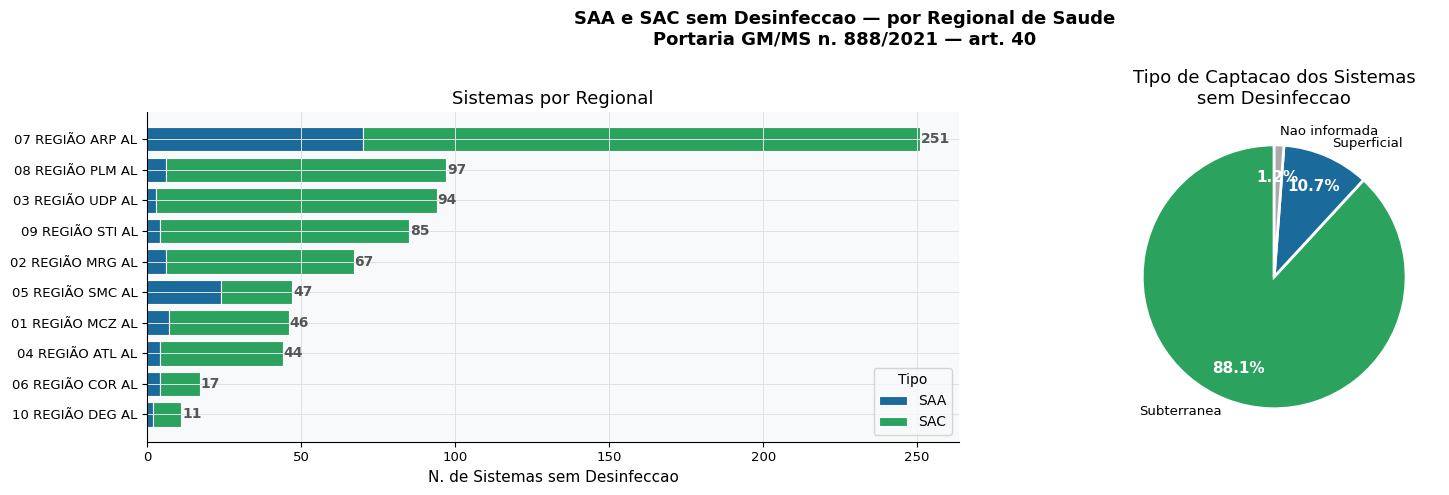

In [18]:
# @title Grafico: distribuicao por regional e captacao
# Grafico: SAA+SAC sem desinfeccao por regional
import matplotlib.pyplot as plt
import numpy as np

BG = '#f8f9fa'
CORES_TIPO = {'SAA':'#1a6b9b','SAC':'#2ca25f','SAI':'#e07b39'}

por_reg = sem_desinf.groupby(['Regional','Tipo']).size().unstack(fill_value=0)
for c in ['SAA','SAC']:
    if c not in por_reg.columns: por_reg[c] = 0
por_reg['Total'] = por_reg[['SAA','SAC']].sum(axis=1)
por_reg = por_reg.sort_values('Total', ascending=True)

fig, axes = plt.subplots(1,2,figsize=(17,5))
fig.suptitle('SAA e SAC sem Desinfeccao — por Regional de Saude\n'
             'Portaria GM/MS n. 888/2021 — art. 40',
             fontsize=13, fontweight='bold')

# Barras empilhadas por regional
ax = axes[0]
bottom = np.zeros(len(por_reg))
for tipo in ['SAA','SAC']:
    if tipo in por_reg.columns:
        vals = por_reg[tipo].values
        ax.barh(por_reg.index, vals, left=bottom,
                color=CORES_TIPO[tipo], label=tipo, edgecolor='white', linewidth=0.8)
        bottom += vals
for i,(idx,row) in enumerate(por_reg.iterrows()):
    ax.text(row['Total']+0.3, i, str(int(row['Total'])),
            va='center', fontsize=10, fontweight='bold', color='#555')
ax.set_xlabel('N. de Sistemas sem Desinfeccao')
ax.set_title('Sistemas por Regional')
ax.legend(title='Tipo')

# Pizza: distribuicao por captacao
ax = axes[1]
dist_cap = sem_desinf['Captacao'].value_counts()
cores_cap = {'Superficial':'#1a6b9b','Subterranea':'#2ca25f','Nao informada':'#aaaaaa'}
cores_p = [cores_cap.get(c,'#aaa') for c in dist_cap.index]
wedges,texts,autotexts = ax.pie(
    dist_cap.values, labels=dist_cap.index, colors=cores_p,
    autopct='%1.1f%%', startangle=90, pctdistance=0.75,
    wedgeprops={'edgecolor':'white','linewidth':2})
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight('bold'); at.set_color('white')
ax.set_title('Tipo de Captacao dos Sistemas\nsem Desinfeccao')

plt.tight_layout()
plt.savefig('fig11_sem_desinf_regional.png',dpi=150,bbox_inches='tight')
plt.show()

In [19]:
# @title Resumo por municipio
# Tabela completa por municipio (para uso operacional)
por_mun = sem_desinf.groupby(['Municipio','Tipo']).agg(
    N_Sistemas=('Sistema','count'),
    Pop_Estimada=('Pop. Estimada','sum'),
    N_Superficial=('Captacao', lambda x:(x=='Superficial').sum()),
    N_Subterranea=('Captacao', lambda x:(x=='Subterranea').sum()),
).reset_index().sort_values('Pop_Estimada', ascending=False)

print('Top 20 municipios por populacao estimada sem desinfeccao (SAA+SAC):')
por_mun.head(20)

Top 20 municipios por populacao estimada sem desinfeccao (SAA+SAC):


,Municipio,Tipo,N_Sistemas,Pop_Estimada,N_Superficial,N_Subterranea
34,IGACI,SAC,53,30279.0,4,47
86,SAO SEBASTIAO,SAC,43,29112.0,0,41
14,CAMPO ALEGRE,SAA,4,22568.0,1,3
7,BATALHA,SAC,1,16448.0,1,0
47,LIMOEIRO DE ANADIA,SAA,18,14131.0,1,17
84,SAO LUIS DO QUITUNDE,SAC,4,9781.0,0,4
1,ANADIA,SAC,10,9397.0,0,10
2,ARAPIRACA,SAC,20,8601.0,0,20
69,POCO DAS TRINCHEIRAS,SAC,19,7904.0,2,17
95,VICOSA,SAC,13,7776.0,0,13


In [20]:
# @title Gerar PDF e Excel de pendencias
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'reportlab', 'openpyxl'])
print('Dependencias prontas.')

import pandas as pd
import numpy as np
import re
import unicodedata
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.units import cm
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_LEFT, TA_CENTER
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer,
                                 Table, TableStyle, HRFlowable, PageBreak)
import openpyxl
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# ── RECRIAR DADOS DO ZERO ──────────────────────────────────────────────────────
df_raw = pd.read_csv(
    'cadastro_populacao_abastecida_AL.csv',
    encoding='latin-1', sep=None, engine='python'
)
df_raw['ECON_PERM'] = df_raw['NU_ECONOMIA_DOMICILIO_PERMAN'].fillna(0)
df_raw['DESINF']    = (df_raw['DESINFECCAO'] == 'Sim').astype(int)
df_raw['POP']       = df_raw['NU_VALOR_POPULACAO_ESTIMADA'].fillna(0)
df_raw['REG_NUM']   = df_raw['NO_REGIONAL'].apply(
    lambda x: re.search(r'(\d+)', str(x)).group(1).zfill(2)
              if re.search(r'(\d+)', str(x)) else '??')

# SAA e SAC sem desinfeccao
df_sd = df_raw[
    (df_raw['TP_ABASTECIMENTO'].isin(['SAA','SAC'])) &
    (df_raw['DESINF'] == 0)
][['NO_MUNICIPIO','REG_NUM','TP_ABASTECIMENTO',
   'NO_SOLUCAO_ABASTECIMENTO','POP']]    .sort_values(['REG_NUM','NO_MUNICIPIO','TP_ABASTECIMENTO'])    .reset_index(drop=True)

# SAI com mais de 10 economias
sai_exp = df_raw[
    (df_raw['TP_ABASTECIMENTO'] == 'SAI') &
    (df_raw['ECON_PERM'] > 10)
][['NO_MUNICIPIO','REG_NUM','NO_SOLUCAO_ABASTECIMENTO',
   'ECON_PERM','POP','DESINFECCAO','FILTRACAO']]    .sort_values(['REG_NUM','NO_MUNICIPIO','ECON_PERM'], ascending=[True,True,False])    .reset_index(drop=True)

n_sd    = len(df_sd)
n_sai_a = len(sai_exp)
n_saa_sd = (df_sd['TP_ABASTECIMENTO']=='SAA').sum()
n_sac_sd = (df_sd['TP_ABASTECIMENTO']=='SAC').sum()
n_forte  = ((sai_exp['DESINFECCAO']=='Sim') | (sai_exp['FILTRACAO']=='Sim')).sum()

print(f"SAA+SAC sem desinfeccao : {n_sd} ({n_saa_sd} SAA | {n_sac_sd} SAC)")
print(f"SAI com > 10 economias  : {n_sai_a} ({n_forte} com tratamento)")

# ── ESTILOS REPORTLAB ─────────────────────────────────────────────────────────
AZUL_ESC  = colors.HexColor('#1a3a5c')
AZUL_MED  = colors.HexColor('#1a6b9b')
AZUL_CLAR = colors.HexColor('#d6e8f5')
LARANJA   = colors.HexColor('#e07b39')
VERMELHO  = colors.HexColor('#c0392b')
CINZA_LIN = colors.HexColor('#dee2e6')
BRANCO    = colors.white

styles = getSampleStyleSheet()
def estilo(nome, pai='Normal', **kw):
    return ParagraphStyle(nome, parent=styles[pai], **kw)

s_titulo = estilo('T', fontSize=16, textColor=AZUL_ESC,
                  fontName='Helvetica-Bold', spaceAfter=4, alignment=TA_CENTER)
s_subtit = estilo('S', fontSize=10, textColor=AZUL_MED,
                  fontName='Helvetica', spaceAfter=2, alignment=TA_CENTER)
s_data   = estilo('D', fontSize=8.5, textColor=colors.grey,
                  fontName='Helvetica', spaceAfter=0, alignment=TA_CENTER)
s_sec    = estilo('SE', fontSize=12, textColor=BRANCO,
                  fontName='Helvetica-Bold', spaceAfter=0, spaceBefore=10, leftIndent=8)
s_nota   = estilo('N', fontSize=8.5, textColor=colors.HexColor('#555555'),
                  fontName='Helvetica-Oblique', leftIndent=10, spaceAfter=6)
s_cell   = estilo('C',  fontSize=8, fontName='Helvetica', leading=10)
s_cell_b = estilo('CB', fontSize=8, fontName='Helvetica-Bold', leading=10)
s_cell_c = estilo('CC', fontSize=8, fontName='Helvetica-Bold',
                  leading=10, alignment=TA_CENTER)
s_res    = estilo('R', fontSize=10, textColor=AZUL_ESC,
                  fontName='Helvetica-Bold', alignment=TA_CENTER, spaceAfter=2)

def bloco_sec(texto, cor=AZUL_MED):
    t = Table([[Paragraph(texto, s_sec)]], colWidths=[17.2*cm])
    t.setStyle(TableStyle([
        ('BACKGROUND',(0,0),(-1,-1),cor),
        ('ROWPADDING',(0,0),(-1,-1),6),
        ('BOTTOMPADDING',(0,0),(-1,-1),6),
    ]))
    return t

def card(label, val, cor=AZUL_MED):
    t = Table([
        [Paragraph(f'<font size=20><b>{val}</b></font>', s_res)],
        [Paragraph(label, s_res)]
    ], colWidths=[5.5*cm])
    t.setStyle(TableStyle([
        ('BACKGROUND',(0,0),(-1,-1),AZUL_CLAR),
        ('ROWPADDING',(0,0),(-1,-1),6),
        ('VALIGN',(0,0),(-1,-1),'MIDDLE'),
        ('BOX',(0,0),(-1,-1),0.5,cor),
    ]))
    return t

def tab_sd(data):
    hdr = [Paragraph(f'<b>{h}</b>', s_cell_b)
           for h in ['Municipio','Regional','Tipo','Sistema','Pop. Est.']]
    rows = [hdr]
    for _, r in data.iterrows():
        tipo = r['TP_ABASTECIMENTO']
        rows.append([
            Paragraph(str(r['NO_MUNICIPIO']).title(), s_cell),
            Paragraph(str(r['REG_NUM']), s_cell_c),
            Paragraph(str(tipo), s_cell_c),
            Paragraph(str(r['NO_SOLUCAO_ABASTECIMENTO']).title()[:62], s_cell),
            Paragraph(f"{int(r['POP']):,}" if r['POP']>0 else '-', s_cell_c),
        ])
    tbl = Table(rows, colWidths=[3.6*cm,2*cm,1.8*cm,7.6*cm,2.2*cm], repeatRows=1)
    cmds = [
        ('BACKGROUND',(0,0),(-1,0),AZUL_MED),
        ('TEXTCOLOR',(0,0),(-1,0),BRANCO),
        ('FONTNAME',(0,0),(-1,0),'Helvetica-Bold'),
        ('FONTSIZE',(0,0),(-1,0),8),
        ('ROWPADDING',(0,0),(-1,-1),3),
        ('BOTTOMPADDING',(0,0),(-1,-1),3),
        ('GRID',(0,0),(-1,-1),0.3,CINZA_LIN),
        ('VALIGN',(0,0),(-1,-1),'MIDDLE'),
        ('ALIGN',(1,1),(2,-1),'CENTER'),
        ('ALIGN',(4,1),(4,-1),'CENTER'),
    ]
    for i, (_, r) in enumerate(data.iterrows(), start=1):
        tipo = r['TP_ABASTECIMENTO']
        bg = (colors.HexColor('#d0e8f5') if tipo=='SAA' else colors.HexColor('#d0eedd'))              if i%2==0 else              (colors.HexColor('#e8f4fb') if tipo=='SAA' else colors.HexColor('#e8f7ee'))
        cmds.append(('BACKGROUND',(0,i),(-1,i),bg))
    tbl.setStyle(TableStyle(cmds))
    return tbl

def tab_sai(data):
    hdr = [Paragraph(f'<b>{h}</b>', s_cell_b)
           for h in ['Municipio','Regional','Sistema','Economias','Pop. Est.','Trat.?']]
    rows = [hdr]
    for _, r in data.iterrows():
        forte = r['DESINFECCAO']=='Sim' or r['FILTRACAO']=='Sim'
        rows.append([
            Paragraph(str(r['NO_MUNICIPIO']).title(), s_cell),
            Paragraph(str(r['REG_NUM']), s_cell_c),
            Paragraph(str(r['NO_SOLUCAO_ABASTECIMENTO']).title()[:60], s_cell),
            Paragraph(str(int(r['ECON_PERM'])), s_cell_c),
            Paragraph(f"{int(r['POP']):,}" if r['POP']>0 else '-', s_cell_c),
            Paragraph('Sim' if forte else 'Nao', s_cell_c),
        ])
    tbl = Table(rows, colWidths=[3.3*cm,1.9*cm,7.4*cm,2*cm,2*cm,1.6*cm], repeatRows=1)
    cmds = [
        ('BACKGROUND',(0,0),(-1,0),LARANJA),
        ('TEXTCOLOR',(0,0),(-1,0),BRANCO),
        ('FONTNAME',(0,0),(-1,0),'Helvetica-Bold'),
        ('FONTSIZE',(0,0),(-1,0),8),
        ('ROWPADDING',(0,0),(-1,-1),3),
        ('BOTTOMPADDING',(0,0),(-1,-1),3),
        ('GRID',(0,0),(-1,-1),0.3,CINZA_LIN),
        ('VALIGN',(0,0),(-1,-1),'MIDDLE'),
        ('ALIGN',(1,1),(1,-1),'CENTER'),
        ('ALIGN',(3,1),(5,-1),'CENTER'),
    ]
    for i, (_, r) in enumerate(data.iterrows(), start=1):
        forte = r['DESINFECCAO']=='Sim' or r['FILTRACAO']=='Sim'
        bg = (colors.HexColor('#fad7d0') if forte else colors.HexColor('#fdebd0'))              if i%2==0 else              (colors.HexColor('#fce8e4') if forte else colors.HexColor('#fef9f4'))
        cmds.append(('BACKGROUND',(0,i),(-1,i),bg))
    tbl.setStyle(TableStyle(cmds))
    return tbl

# ── GERAR PDF ─────────────────────────────────────────────────────────────────
out_pdf = 'pendencias_SISAGUA_AL_2026.pdf'
doc = SimpleDocTemplate(out_pdf, pagesize=A4,
    leftMargin=1.8*cm, rightMargin=1.8*cm,
    topMargin=2*cm, bottomMargin=2*cm)

story = []
story.append(Spacer(1,0.3*cm))
story.append(Paragraph('Relatorio de Pendencias Cadastrais', s_titulo))
story.append(Paragraph('Sistemas de Abastecimento de Agua - Alagoas 2026', s_subtit))
story.append(Paragraph('SEVISA / SESAU-AL - Vigilancia da Qualidade da Agua', s_data))
story.append(Spacer(1,0.3*cm))
story.append(HRFlowable(width='100%', thickness=2, color=AZUL_MED))
story.append(Spacer(1,0.3*cm))

c_tbl = Table([
    [card('SAA e SAC\nsem desinfeccao', str(n_sd)),
     card('SAI com\n> 10 economias', str(n_sai_a), LARANJA),
     card('Total de\npendencias', str(n_sd+n_sai_a), VERMELHO)]
], colWidths=[5.8*cm, 5.8*cm, 5.8*cm])
c_tbl.setStyle(TableStyle([
    ('VALIGN',(0,0),(-1,-1),'MIDDLE'),
    ('LEFTPADDING',(0,0),(-1,-1),4),
    ('RIGHTPADDING',(0,0),(-1,-1),4),
]))
story.append(c_tbl)
story.append(Spacer(1,0.3*cm))
story.append(Paragraph(
    'Base normativa: Portaria GM/MS n. 888/2021 - '
    'Art. 5 (definicao de SAI) | Art. 40 (obrigatoriedade de desinfeccao em SAA e SAC)',
    s_nota))
story.append(HRFlowable(width='100%', thickness=0.5, color=CINZA_LIN))
story.append(Spacer(1,0.2*cm))

story.append(bloco_sec(f'1. SAA e SAC sem Desinfeccao  ({n_sd} sistemas)', AZUL_MED))
story.append(Spacer(1,0.2*cm))
story.append(Paragraph(
    f'Portaria GM/MS n. 888/2021 - art. 40: desinfeccao obrigatoria em SAA e SAC. '
    f'SAA sem desinfeccao: {n_saa_sd} | SAC sem desinfeccao: {n_sac_sd}', s_nota))
story.append(Spacer(1,0.1*cm))
story.append(tab_sd(df_sd))

story.append(PageBreak())
story.append(bloco_sec(f'2. SAI com mais de 10 Economias  ({n_sai_a} sistemas)', LARANJA))
story.append(Spacer(1,0.2*cm))
story.append(Paragraph(
    f'Portaria GM/MS n. 888/2021 - art. 5: SAI deve atender um unico domicilio. '
    f'Sistemas com > 10 economias devem ser reclassificados como SAC. '
    f'Com tratamento (indicio forte): {n_forte} | Sem tratamento: {n_sai_a-n_forte}', s_nota))
story.append(Spacer(1,0.1*cm))
story.append(tab_sai(sai_exp))
story.append(Spacer(1,0.4*cm))
story.append(HRFlowable(width='100%', thickness=0.5, color=CINZA_LIN))
story.append(Spacer(1,0.15*cm))
story.append(Paragraph(
    'SEVISA / SESAU-AL | Dados: SISAGUA (ref. 2026) | Portaria GM/MS n. 888/2021',
    estilo('Rod', fontSize=7.5, textColor=colors.grey,
           fontName='Helvetica-Oblique', alignment=TA_CENTER)))

doc.build(story)
print(f'PDF gerado: {out_pdf}')

# ── GERAR EXCEL ───────────────────────────────────────────────────────────────
wb = openpyxl.Workbook()
azul_f  = PatternFill('solid', fgColor='1a6b9b')
verde_f = PatternFill('solid', fgColor='2ca25f')
larj_f  = PatternFill('solid', fgColor='e07b39')
az_cl   = PatternFill('solid', fgColor='e8f4fb')
az_z    = PatternFill('solid', fgColor='d0e8f5')
vd_cl   = PatternFill('solid', fgColor='e8f7ee')
vd_z    = PatternFill('solid', fgColor='d0eedd')
lj_cl   = PatternFill('solid', fgColor='fef9f4')
lj_z    = PatternFill('solid', fgColor='fdebd0')
vm_cl   = PatternFill('solid', fgColor='fce8e4')
vm_z    = PatternFill('solid', fgColor='fad7d0')
wht_fnt = Font(color='FFFFFF', bold=True, size=9)
thin    = Side(style='thin', color='dee2e6')
brd     = Border(left=thin, right=thin, top=thin, bottom=thin)
c_aln   = Alignment(horizontal='center', vertical='center', wrap_text=True)
l_aln   = Alignment(horizontal='left',   vertical='center', wrap_text=True)

# Aba 1: SAA+SAC sem desinfeccao
ws1 = wb.active
ws1.title = 'SAA-SAC sem Desinfeccao'
ws1.merge_cells('A1:E1')
ws1['A1'].value = 'SAA e SAC sem Desinfeccao - SISAGUA Alagoas 2026'
ws1['A1'].font = Font(bold=True, size=13, color='1a3a5c')
ws1['A1'].alignment = c_aln
ws1.row_dimensions[1].height = 28
ws1.merge_cells('A2:E2')
ws1['A2'].value = f'Total: {n_sd} sistemas | Portaria GM/MS n. 888/2021 - art. 40'
ws1['A2'].font = Font(italic=True, size=9, color='555555')
ws1['A2'].alignment = c_aln
ws1.row_dimensions[2].height = 16
for col, h in enumerate(['Municipio','Regional','Tipo','Sistema','Pop. Estimada'], 1):
    c = ws1.cell(row=3, column=col, value=h)
    c.fill = azul_f; c.font = wht_fnt; c.alignment = c_aln; c.border = brd
ws1.row_dimensions[3].height = 22
for ri, (_, r) in enumerate(df_sd.iterrows(), start=4):
    tipo = r['TP_ABASTECIMENTO']
    bg = (az_z if tipo=='SAA' else vd_z) if ri%2==0 else (az_cl if tipo=='SAA' else vd_cl)
    vals = [str(r['NO_MUNICIPIO']).title(), str(r['REG_NUM']),
            str(tipo), str(r['NO_SOLUCAO_ABASTECIMENTO']).title(),
            int(r['POP']) if r['POP']>0 else '']
    alns = [l_aln, c_aln, c_aln, l_aln, c_aln]
    for col, (v, a) in enumerate(zip(vals, alns), 1):
        c = ws1.cell(row=ri, column=col, value=v)
        c.fill = bg; c.alignment = a; c.border = brd; c.font = Font(size=8.5)
    ws1.row_dimensions[ri].height = 15
for col, w in zip([1,2,3,4,5], [22,9,8,42,12]):
    ws1.column_dimensions[get_column_letter(col)].width = w

# Aba 2: SAI > 10 economias
ws2 = wb.create_sheet('SAI mais 10 Economias')
ws2.merge_cells('A1:F1')
ws2['A1'].value = 'SAI com mais de 10 Economias - SISAGUA Alagoas 2026'
ws2['A1'].font = Font(bold=True, size=13, color='1a3a5c')
ws2['A1'].alignment = c_aln
ws2.row_dimensions[1].height = 28
ws2.merge_cells('A2:F2')
ws2['A2'].value = (f'Total: {n_sai_a} | Com tratamento: {n_forte} | '
                   f'Portaria GM/MS n. 888/2021 - art. 5')
ws2['A2'].font = Font(italic=True, size=9, color='555555')
ws2['A2'].alignment = c_aln
ws2.row_dimensions[2].height = 16
for col, h in enumerate(['Municipio','Regional','Sistema','Economias','Pop. Estimada','Tem Tratamento?'], 1):
    c = ws2.cell(row=3, column=col, value=h)
    c.fill = larj_f; c.font = wht_fnt; c.alignment = c_aln; c.border = brd
ws2.row_dimensions[3].height = 22
for ri, (_, r) in enumerate(sai_exp.iterrows(), start=4):
    forte = r['DESINFECCAO']=='Sim' or r['FILTRACAO']=='Sim'
    bg = (vm_z if forte else lj_z) if ri%2==0 else (vm_cl if forte else lj_cl)
    vals = [str(r['NO_MUNICIPIO']).title(), str(r['REG_NUM']),
            str(r['NO_SOLUCAO_ABASTECIMENTO']).title(),
            int(r['ECON_PERM']), int(r['POP']) if r['POP']>0 else '',
            'Sim' if forte else 'Nao']
    alns = [l_aln, c_aln, l_aln, c_aln, c_aln, c_aln]
    for col, (v, a) in enumerate(zip(vals, alns), 1):
        c = ws2.cell(row=ri, column=col, value=v)
        c.fill = bg; c.alignment = a; c.border = brd; c.font = Font(size=8.5)
    ws2.row_dimensions[ri].height = 15
for col, w in zip([1,2,3,4,5,6], [22,9,42,11,13,15]):
    ws2.column_dimensions[get_column_letter(col)].width = w

out_xl = 'pendencias_SISAGUA_AL_2026.xlsx'
wb.save(out_xl)
print(f'Excel gerado: {out_xl}')
print('Arquivos salvos na pasta do projeto Colab.')


Dependencias prontas.
SAA+SAC sem desinfeccao : 759 (130 SAA | 629 SAC)
SAI com > 10 economias  : 136 (24 com tratamento)
PDF gerado: pendencias_SISAGUA_AL_2026.pdf
Excel gerado: pendencias_SISAGUA_AL_2026.xlsx
Arquivos salvos na pasta do projeto Colab.


In [21]:
# @title Exportacao consolidada — use a celula "Gerar PDF e Excel de pendencias"
print("Esta celula foi substituida.")
print("Use a celula \"Gerar PDF e Excel de pendencias\" para exportar.")
print("Ela e autoconida e nao depende de celulas anteriores.")

Esta celula foi substituida.
Use a celula "Gerar PDF e Excel de pendencias" para exportar.
Ela e autoconida e nao depende de celulas anteriores.


### 6.2 SAI com mais de 10 Economias

In [22]:
# @title Listagem SAI com mais de 10 economias
# SAI com > 10 economias
sai_lista = df[
    (df['TP_ABASTECIMENTO']=='SAI') &
    (df['ECON_PERM'] > 10)
][[
    'NO_MUNICIPIO','REGIONAL','NO_SOLUCAO_ABASTECIMENTO',
    'ECON_PERM','POP','SUP','SUB',
    'DESINFECCAO','FILTRACAO','DT_FORMULARIO_CADASTRO'
]].copy()

sai_lista['CAPTACAO'] = sai_lista.apply(
    lambda r: 'Superficial' if r['SUP']==1
    else ('Subterranea' if r['SUB']==1 else 'Nao informada'), axis=1)

sai_lista['INDICIO'] = sai_lista.apply(
    lambda r: 'Forte (trat. + economias)' if (r['DESINFECCAO']=='Sim' or r['FILTRACAO']=='Sim')
    else 'Moderado (so economias)', axis=1)

sai_lista = sai_lista.drop(columns=['SUP','SUB'])\
    .rename(columns={
        'NO_MUNICIPIO':'Municipio','REGIONAL':'Regional',
        'NO_SOLUCAO_ABASTECIMENTO':'Sistema',
        'ECON_PERM':'Economias','POP':'Pop. Estimada',
        'CAPTACAO':'Captacao','DESINFECCAO':'Desinfeccao',
        'FILTRACAO':'Filtracao','DT_FORMULARIO_CADASTRO':'Dt. Cadastro',
        'INDICIO':'Indicio de Equivoco'
    })\
    .sort_values('Economias', ascending=False)\
    .reset_index(drop=True)

sai_lista.index += 1

forte  = (sai_lista['Indicio de Equivoco']=='Forte (trat. + economias)').sum()
moder  = (sai_lista['Indicio de Equivoco']=='Moderado (so economias)').sum()
pop_sai = sai_lista['Pop. Estimada'].sum()

print(f'SAI com > 10 economias             : {len(sai_lista)}')
print(f'  Indicio forte (com tratamento)   : {forte}')
print(f'  Indicio moderado (so economias)  : {moder}')
print(f'Pop. estimada total nestes SAI     : {pop_sai:,.0f} hab.')
print()
print('Referencia: Portaria GM/MS 888/2021, art. 5')
sai_lista

SAI com > 10 economias             : 136
  Indicio forte (com tratamento)   : 24
  Indicio moderado (so economias)  : 112
Pop. estimada total nestes SAI     : 39,889 hab.

Referencia: Portaria GM/MS 888/2021, art. 5


,Municipio,Regional,Sistema,Economias,Pop. Estimada,Desinfeccao,Filtracao,Dt. Cadastro,Captacao,Indicio de Equivoco
1,AGUA BRANCA,10 REGIÃO DEG AL,SAI DE AGUA BRANCA GRUPO DE CISTERNAS DE PLACA,999.0,3327.0,NaN,NaN,2026/01/14 00:00:00.000000000,Nao informada,Moderado (so economias)
2,OLIVENCA,09 REGIÃO STI AL,SAI DE OLIVENCA BOM SUCESSO,685.0,2069.0,Não,Não,2026/01/12 00:00:00.000000000,Superficial,Moderado (so economias)
3,SAO SEBASTIAO,07 REGIÃO ARP AL,SAI DE SAO SEBASTIAO BELISCA PAU,630.0,1903.0,Não,Não,2026/01/13 00:00:00.000000000,Subterranea,Moderado (so economias)
4,SAO SEBASTIAO,07 REGIÃO ARP AL,SAI DE SAO SEBASTIAO SITIO LAGOA SECA,450.0,1359.0,Não,Não,2026/01/13 00:00:00.000000000,Subterranea,Moderado (so economias)
5,ROTEIRO,05 REGIÃO SMC AL,SAI DE ROTEIRO BAIXADA DA CAMBOA,350.0,1141.0,Não,Não,2026/01/06 00:00:00.000000000,Subterranea,Moderado (so economias)
...,...,...,...,...,...,...,...,...,...,...
132,FLEXEIRAS,01 REGIÃO MCZ AL,SAI DE FLEXEIRAS GRUPO FAZENDA INDEPENDENCIA,13.0,40.0,Sim,NaN,2026/02/23 00:00:00.000000000,Subterranea,Forte (trat. + economias)
133,BELEM,08 REGIÃO PLM AL,SAI DE BELEM GRUPO VARZEA DO ARROZ,13.0,37.0,NaN,NaN,2026/02/11 00:00:00.000000000,Subterranea,Moderado (so economias)
134,SANTANA DO MUNDAU,03 REGIÃO UDP AL,SAI FAZENDA PENHA,12.0,36.0,Não,Não,2026/01/16 00:00:00.000000000,Subterranea,Moderado (so economias)
135,FLEXEIRAS,01 REGIÃO MCZ AL,SAI DE FLEXEIRAS ZONA URBANA,11.0,34.0,Não,Não,2026/02/05 00:00:00.000000000,Subterranea,Moderado (so economias)


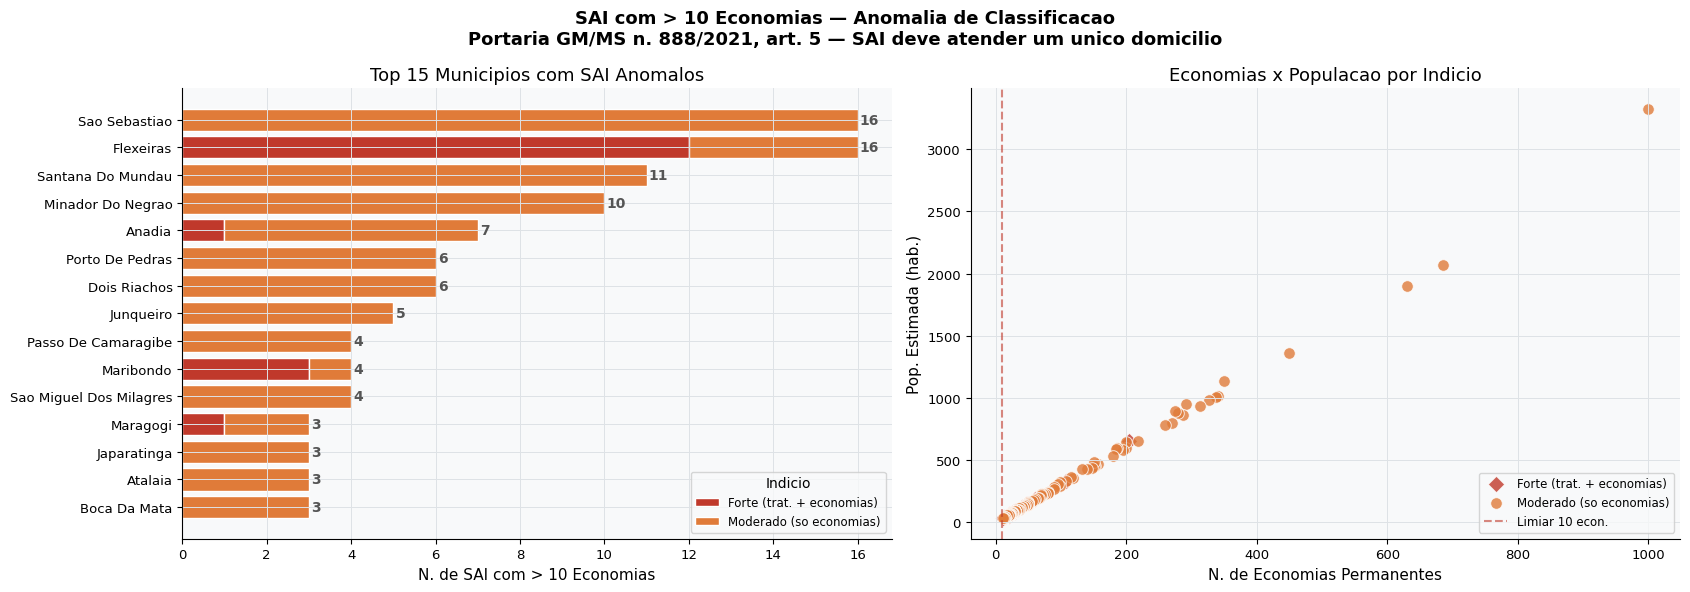

In [23]:
# @title Grafico: SAI anomalos por municipio
# Grafico: SAI anomalos por municipio e indicio
por_mun_sai = sai_lista.groupby(['Municipio','Indicio de Equivoco']).agg(
    N=('Economias','count'),
    Econ_Total=('Economias','sum'),
    Pop_Total=('Pop. Estimada','sum')
).reset_index()

pivot = por_mun_sai.pivot_table(
    index='Municipio', columns='Indicio de Equivoco',
    values='N', fill_value=0)
pivot['Total'] = pivot.sum(axis=1)
pivot = pivot.sort_values('Total', ascending=True).tail(15)

fig, axes = plt.subplots(1,2,figsize=(17,6))
fig.suptitle('SAI com > 10 Economias — Anomalia de Classificacao\n'
             'Portaria GM/MS n. 888/2021, art. 5 — SAI deve atender um unico domicilio',
             fontsize=13, fontweight='bold')

# Barras: municipios
ax = axes[0]
bottom = np.zeros(len(pivot))
cores_ind = ['#c0392b','#e07b39']
for col,cor in zip(['Forte (trat. + economias)','Moderado (so economias)'],cores_ind):
    if col in pivot.columns:
        vals = pivot[col].values
        ax.barh(pivot.index.str.title(), vals, left=bottom,
                color=cor, label=col, edgecolor='white')
        bottom += vals
for i,(idx,row) in enumerate(pivot.iterrows()):
    ax.text(row['Total']+0.05, i, str(int(row['Total'])),
            va='center', fontsize=10, fontweight='bold', color='#555')
ax.set_xlabel('N. de SAI com > 10 Economias')
ax.set_title('Top 15 Municipios com SAI Anomalos')
ax.legend(title='Indicio', fontsize=8.5)

# Dispersao economias x pop com destaque por indicio
ax = axes[1]
for indicio, cor, marker in [
    ('Forte (trat. + economias)', '#c0392b', 'D'),
    ('Moderado (so economias)',   '#e07b39', 'o'),
]:
    sub = sai_lista[sai_lista['Indicio de Equivoco']==indicio]
    ax.scatter(sub['Economias'], sub['Pop. Estimada'],
               c=cor, s=70, alpha=0.8, marker=marker,
               edgecolors='white', linewidths=0.7, label=indicio)

ax.axvline(10,color='#c0392b',linestyle='--',alpha=0.6,linewidth=1.5,label='Limiar 10 econ.')
ax.set_xlabel('N. de Economias Permanentes')
ax.set_ylabel('Pop. Estimada (hab.)')
ax.set_title('Economias x Populacao por Indicio')
ax.legend(fontsize=8.5)

plt.tight_layout()
plt.savefig('fig12_sai_lista.png',dpi=150,bbox_inches='tight')
plt.show()

In [24]:
# @title Exportacao consolidada na secao anterior
print("Ver exportacao na secao 6.1 — PDF e Excel gerados.")

Ver exportacao na secao 6.1 — PDF e Excel gerados.


In [25]:
# @title Indicadores finais consolidados
pop_ibge_t = df_m['POP_IBGE'].sum()
pop_sis_t  = df_m['POP_SISAGUA'].sum()
sub_sc     = df[df['TP_ABASTECIMENTO'].isin(['SAA','SAC'])]
sub_sup    = sub_sc[sub_sc['SUP']==1]

print('='*65)
print('RELATORIO INTEGRADO - ABASTECIMENTO DE AGUA / ALAGOAS 2026')
print('='*65)
print(f'Solucoes SISAGUA         : {len(df):,} ({cont["SAA"]} SAA | {cont["SAC"]} SAC | {cont["SAI"]} SAI)')
print(f'Municipios cobertos       : {df["NO_MUNICIPIO"].nunique()} de 102')
print(f'Pop. estimada SISAGUA     : {pop_sis_t:,.0f} hab.')
print(f'Pop. recenseada IBGE 2022 : {pop_ibge_t:,.0f} hab.')
print(f'Cobertura estadual        : {pop_sis_t/pop_ibge_t*100:.1f}%')
print()
print('Qualidade SAA+SAC (Portaria 888/2021):')
print(f'  Desinfeccao             : {sub_sc["DESINF"].mean()*100:.1f}%')
print(f'  Filtracao (sup.)        : {sub_sup["FILTR"].mean()*100:.1f}%' if len(sub_sup)>0 else '  Filtracao (sup.)        : 0.0%')
print()
print('Anomalias cadastrais:')
print(f'  SAI com > 10 economias  : {len(sai_anomalo)} sistemas em {sai_anomalo["NO_MUNICIPIO"].nunique()} municipios')
print(f'    Com desinfec./filtracao: {(sai_anomalo["TEM_TRAT"]=="Sim").sum()} (duplo indicio)')
print(f'  Outras anomalias         : {len(df_outras)} municipios')
print(f'  Municipios sem SAA       : {(df_m["N_SAA"]==0).sum()}')
print('='*65)

RELATORIO INTEGRADO - ABASTECIMENTO DE AGUA / ALAGOAS 2026
Solucoes SISAGUA         : 1,970 (771 SAA | 779 SAC | 420 SAI)
Municipios cobertos       : 101 de 102
Pop. estimada SISAGUA     : 2,432,708 hab.
Pop. recenseada IBGE 2022 : 3,125,254 hab.
Cobertura estadual        : 77.8%

Qualidade SAA+SAC (Portaria 888/2021):
  Desinfeccao             : 51.0%
  Filtracao (sup.)        : 33.7%

Anomalias cadastrais:
  SAI com > 10 economias  : 136 sistemas em 37 municipios
    Com desinfec./filtracao: 24 (duplo indicio)
  Outras anomalias         : 6 municipios
  Municipios sem SAA       : 1


### Recomendacoes para SEVISA/SESAU-AL

| # | Prioridade | Acao | Base normativa |
|---|-----------|------|---------------|
| 1 | **Alta** | Notificar prestadores para revisao e reclassificacao dos SAI com > 10 economias como SAC | Portaria 888/2021, art. 5 |
| 2 | **Alta** | Cadastrar SAA de Murici — 25.221 hab sem registro no SISAGUA | Portaria 888/2021, art. 10 |
| 3 | **Media** | Corrigir duplicidade de populacao em Poco das Trincheiras e valores superestimados em Batalha, Estrela, Anadia e Belem | — |
| 4 | **Media** | Intensificar coleta de amostras nos SAC sem desinfeccao com captacao subterranea | Portaria 888/2021, art. 40 |
| 5 | **Atencao** | Cruzar dados com resultados laboratoriais do SISAGUA para incluir sistemas subterraneos com E. coli positivo na analise de filtracao | Portaria 888/2021, Anexo XX |
| 6 | **Atencao** | Monitorar municipios com dependencia de SAA intermunicipal — vulnerabilidade em caso de interrupcao da adutora | — |

---

### Nota metodologica

| Analise | SAA | SAC | SAI |
|---------|-----|-----|-----|
| Desinfeccao | Incluido | Incluido | Exibido para contexto geral |
| Filtracao (manancial superficial) | Incluido | Incluido | Excluido |
| Filtracao (subterraneo c/ E.coli+) | Analise futura | Analise futura | Excluido |
| Anomalia de classificacao | — | — | > 10 economias = anomalia |

---
*SEVISA / SESAU-AL - Vigilancia da Qualidade da Agua para Consumo Humano*  
*Dados: SISAGUA (ref. 2026) x IBGE Censo Demografico 2022*  
*Base normativa: Portaria GM/MS n. 888, de 4 de maio de 2021*